# SEM Parallel Mediation Analysis: APOE4 SNP -> Gene Expression -> CAA Neuropathology

## Aim

This notebook tests whether four gene expression mediators (APOC4/APOC2, APOC2, APOC1, APOE) **jointly and independently** mediate the effect of the APOE4 region SNP (chr19_44954310_T_C) on cerebral amyloid angiopathy neuropathology (caa_neo4), using a parallel mediation SEM framework with partially overlapping samples.

**Design:** Parallel mediation (Design 2) -- all four mediators enter the outcome equation simultaneously, allowing estimation of specific indirect effects (unique contribution of each mediator) and the total indirect effect.

**Direction:** Unidirectional -- SNP -> Mediators -> caa_neo4 only.

**Methods:** FIML SEM, Bootstrap (FIML inside), MNAR Sensitivity, Bayesian SEM (blavaan/Stan).

**Covariate strategy:** Covariates-in-model (Strategy A). Each equation has its own covariates:
- APOC4_APOC2_AC_exp equation: msex_u, age_death_u, pmi_u, ROS_study_u
- APOC2_AC_exp equation: msex_u, age_death_u, pmi_u, ROS_study_u
- APOC1_DeJager_Mic_exp equation: msex_u, age_death_u, pmi_u
- APOE_Mega_Mic_exp equation: msex_u, age_death_u, pmi_u
- caa_neo4 equation: educ, apoe4_dose, msex_u, age_death_u

## Directed Acyclic Graph (DAG)

```
                          a1                       b1
                    +---------> [APOC4_APOC2] ---------+
                    |     a2                       b2   |
                    +---------> [APOC2]       ---------+
 [chr19_44954310]---+     a3                       b3   +---> [caa_neo4]
                    +---------> [APOC1]       ---------+
                    |     a4                       b4   |
                    +---------> [APOE]        ---------+
        |                                                  ^
        +------------------ c' (direct) -------------------+
```

- Specific indirect (APOC4_APOC2): a1 x b1
- Specific indirect (APOC2): a2 x b2
- Specific indirect (APOC1): a3 x b3
- Specific indirect (APOE): a4 x b4
- Total indirect = a1*b1 + a2*b2 + a3*b3 + a4*b4
- Total effect = c' + total indirect

Covariates: msex_u, age_death_u, pmi_u, ROS_study_u (mediator eqs); educ, apoe4_dose, msex_u, age_death_u (outcome eq). Residual correlations among mediators freely estimated.

## Key Findings & Conclusion

### Main Analysis (4-Mediator Parallel Model)

**No significant mediation was detected** through any of the four mediators (APOC4_APOC2, APOC2, APOC1, APOE) for the effect of chr19_44954310_T_C on caa_neo4. This finding is consistent across all four methods (FIML, Bootstrap, MNAR Sensitivity, Bayesian).

- **a-paths (SNP → M):** All four a-paths are significant (p < 0.001), confirming the SNP influences all mediators.
- **b-paths (M → Y):** None of the b-paths reached significance. APOC4_APOC2 (b1 = −0.30, p = 0.46) and APOC2 (b2 = 0.68, p = 0.53) showed large estimates with extremely inflated SEs (~1.0), indicating **severe multicollinearity** between these two mediators.
- **Indirect effects:** No specific indirect effect was significant. The total indirect effect was near zero (−0.005, p = 0.76).
- **Direct effect:** The direct path (cp = 0.158, p < 0.001) is significant and accounts for essentially all of the total effect (0.153, p < 0.001).
- **MNAR sensitivity:** All indirect effects had tipping distances of 0.00 SD, indicating they are fragile — even minimal departures from MAR would alter conclusions.
- **Bayesian:** Posterior probability of direction for the APOE indirect effect was highest (P = 0.90), suggesting this is the most promising mediator, though still not credibly different from zero.
- **Proportion mediated:** Total mediation is −3.1%, essentially zero.

### Sensitivity Analysis (3-Mediator Model, Excluding APOC4_APOC2_AC_exp)

Removing APOC4_APOC2_AC_exp confirmed the **multicollinearity diagnosis**:

- **APOC2 b-path stabilized dramatically:** SE dropped from 1.076 to 0.044 (a 24-fold reduction), and the estimate shifted from +0.678 to −0.067 (p = 0.13). This confirms the original APOC2 b-path was unreliable due to collinearity with APOC4_APOC2.
- **APOE indirect effect remained stable:** 0.016 in both models — the most robust mediator signal.
- **Direct and total effects unchanged:** cp = 0.153 (3-med) vs 0.158 (4-med); total ≈ 0.152 in both.
- **Pairwise contrast:** The APOC2 vs APOE indirect difference became significant (diff_1_3, p = 0.040) in the 3-mediator model, driven by the APOE indirect being positive and the APOC2 indirect being negative.

### Overall Conclusion

The SNP chr19_44954310_T_C has a **significant direct effect** on caa_neo4 (est ≈ 0.15, p < 0.001) that is **not meaningfully mediated** by any of the four molecular traits tested. The APOE-mediated pathway shows the most consistent positive signal (est ≈ 0.016, P(direction) = 0.90) but does not reach significance. The APOC4_APOC2 and APOC2 mediators are too collinear to be reliably distinguished in the same model; the sensitivity analysis excluding APOC4_APOC2 resolves this but does not change the substantive conclusion of minimal mediation.

## Input Specification

| Parameter | Value |
|-----------|-------|
| Data file | `/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/caa_neo4/APOE_ind_set_27_caa_neo4_mediation_all_input.txt` |
| Exposure | chr19_44954310_T_C |
| Mediators | APOC4_APOC2_AC_exp, APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp |
| Outcome | caa_neo4 |
| Design | Parallel mediation (Design 2) |
| Direction | Unidirectional (SNP -> M -> Y) |

## Methods Overview

| Method | Purpose | Missing Data | Key Output |
|--------|---------|-------------|------------|
| FIML SEM (lavaan) | Primary analysis | FIML (all rows used) | ML estimates, SEs, CIs |
| Bootstrap (FIML inside) | Non-parametric CIs | FIML per replicate | Percentile CIs, p-values |
| MNAR Sensitivity | Robustness to MNAR | Delta-shift imputation | Tipping points |
| Bayesian SEM (blavaan) | Posterior inference | Stan data augmentation | Credible intervals, P(direction) |

In [1]:
# ============================================================
# Section 1: Setup -- Libraries, paths, output directories
# ============================================================
suppressPackageStartupMessages({
  library(lavaan)
  library(blavaan)
  library(ggplot2)
  library(gridExtra)
  library(reshape2)
})

# Paths
DATA_FILE <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/caa_neo4/APOE_ind_set_27_caa_neo4_mediation_all_input.txt"
RESULT_DIR <- "/mnt/lustre/home/yl4437/xqtl_flagship/APOE/mediation_partialoverlap_claude/set27/caa_neo4/APOE4_adj"

dir.create(file.path(RESULT_DIR, "main_SEM_FIML"), showWarnings=FALSE, recursive=TRUE)
dir.create(file.path(RESULT_DIR, "bootstrap"), showWarnings=FALSE, recursive=TRUE)
dir.create(file.path(RESULT_DIR, "MNAR_sensitivity"), showWarnings=FALSE, recursive=TRUE)
dir.create(file.path(RESULT_DIR, "bayesian_blavaan"), showWarnings=FALSE, recursive=TRUE)
dir.create(file.path(RESULT_DIR, "summary"), showWarnings=FALSE, recursive=TRUE)

# Variable definitions
EXPOSURE <- "chr19_44954310_T_C"
MEDIATORS <- c("APOC4_APOC2_AC_exp", "APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
MEDIATOR_SHORT <- c("APOC4_APOC2", "APOC2", "APOC1", "APOE")
OUTCOME <- "caa_neo4"
n_med <- length(MEDIATORS)

# Covariates per equation
MED_COVS <- list(
  APOC4_APOC2_AC_exp = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC2_AC_exp = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC1_DeJager_Mic_exp = c("msex_u", "age_death_u", "pmi_u"),
  APOE_Mega_Mic_exp = c("msex_u", "age_death_u", "pmi_u")
)
OUT_COVS <- c("educ", "apoe4_dose", "msex_u", "age_death_u")

ALL_COVS <- unique(c(unlist(MED_COVS), OUT_COVS))

cat("Setup complete.\n")
cat("Exposure:", EXPOSURE, "\n")
cat("Mediators:", paste(MEDIATORS, collapse=", "), "\n")
cat("Outcome:", OUTCOME, "\n")
cat("All covariates:", paste(ALL_COVS, collapse=", "), "\n")

Setup complete.


Exposure: chr19_44954310_T_C 


Mediators: APOC4_APOC2_AC_exp, APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp 


Outcome: caa_neo4 


All covariates: msex_u, age_death_u, pmi_u, ROS_study_u, educ, apoe4_dose 


In [2]:
# ============================================================
# Section 2: Data Loading and Exploration
# ============================================================
dat_raw <- read.delim(DATA_FILE, header=TRUE, sep="\t", stringsAsFactors=FALSE)
cat("Raw data dimensions:", nrow(dat_raw), "rows x", ncol(dat_raw), "columns\n")

# Select only needed columns
keep_cols <- c(EXPOSURE, MEDIATORS, OUTCOME, ALL_COVS)
missing_cols <- setdiff(keep_cols, colnames(dat_raw))
if (length(missing_cols) > 0) stop("Missing columns: ", paste(missing_cols, collapse=", "))

dat <- dat_raw[, keep_cols]

# Convert all to numeric
for (col in colnames(dat)) {
  dat[[col]] <- as.numeric(dat[[col]])
}

# Keep only rows with exposure observed
dat <- dat[!is.na(dat[[EXPOSURE]]), ]
N_total <- nrow(dat)
cat("Analysis sample (exposure observed): N =", N_total, "\n\n")

# Missingness summary
cat("--- Missingness Summary ---\n")
for (v in c(EXPOSURE, MEDIATORS, OUTCOME, ALL_COVS)) {
  n_miss <- sum(is.na(dat[[v]]))
  cat(sprintf("  %-30s: %d missing (%5.1f%%)\n", v, n_miss, 100*n_miss/N_total))
}

Raw data dimensions: 1153 rows x 58 columns


Analysis sample (exposure observed): N = 1153 



--- Missingness Summary ---


  chr19_44954310_T_C            : 0 missing (  0.0%)
  APOC4_APOC2_AC_exp            : 560 missing ( 48.6%)
  APOC2_AC_exp                  : 560 missing ( 48.6%)
  APOC1_DeJager_Mic_exp         : 734 missing ( 63.7%)
  APOE_Mega_Mic_exp             : 420 missing ( 36.4%)
  caa_neo4                      : 103 missing (  8.9%)
  msex_u                        : 13 missing (  1.1%)
  age_death_u                   : 13 missing (  1.1%)
  pmi_u                         : 13 missing (  1.1%)
  ROS_study_u                   : 38 missing (  3.3%)
  educ                          : 40 missing (  3.5%)
  apoe4_dose                    : 47 missing (  4.1%)


In [3]:
# ============================================================
# Section 3: Sample Overlap Structure
# ============================================================
cat("--- Sample Overlap (Mediator x Outcome) ---\n\n")

overlap_rows <- list()
for (m in MEDIATORS) {
  has_m <- !is.na(dat[[m]])
  has_y <- !is.na(dat[[OUTCOME]])
  both <- sum(has_m & has_y)
  m_only <- sum(has_m & !has_y)
  y_only <- sum(!has_m & has_y)
  neither <- sum(!has_m & !has_y)
  overlap_rows[[m]] <- data.frame(
    Mediator=m, Both=both, Med_only=m_only, Out_only=y_only, Neither=neither, Total=N_total
  )
  cat(sprintf("  %-30s: Both=%d, M-only=%d, Y-only=%d, Neither=%d\n", m, both, m_only, y_only, neither))
}
overlap_df <- do.call(rbind, overlap_rows)
print(overlap_df)

--- Sample Overlap (Mediator x Outcome) ---



  APOC4_APOC2_AC_exp            : Both=564, M-only=29, Y-only=486, Neither=74
  APOC2_AC_exp                  : Both=564, M-only=29, Y-only=486, Neither=74
  APOC1_DeJager_Mic_exp         : Both=387, M-only=32, Y-only=663, Neither=71
  APOE_Mega_Mic_exp             : Both=677, M-only=56, Y-only=373, Neither=47


                                   Mediator Both Med_only Out_only Neither
APOC4_APOC2_AC_exp       APOC4_APOC2_AC_exp  564       29      486      74
APOC2_AC_exp                   APOC2_AC_exp  564       29      486      74
APOC1_DeJager_Mic_exp APOC1_DeJager_Mic_exp  387       32      663      71
APOE_Mega_Mic_exp         APOE_Mega_Mic_exp  677       56      373      47
                      Total
APOC4_APOC2_AC_exp     1153
APOC2_AC_exp           1153
APOC1_DeJager_Mic_exp  1153
APOE_Mega_Mic_exp      1153


In [4]:
# ============================================================
# Section 4: Build Parallel Mediation Model
# ============================================================

# Mediator equations (each with its own covariates)
med_eqs <- c()
for (i in seq_len(n_med)) {
  m <- MEDIATORS[i]
  cov_str <- paste(MED_COVS[[m]], collapse=" + ")
  med_eqs <- c(med_eqs, paste0(m, " ~ a", i, " * ", EXPOSURE, " + ", cov_str))
}

# Outcome equation (all mediators + direct + outcome covariates)
med_terms <- paste0("b", seq_len(n_med), " * ", MEDIATORS, collapse=" + ")
out_cov_str <- paste(OUT_COVS, collapse=" + ")
y_eq <- paste0(OUTCOME, " ~ ", med_terms, " + cp * ", EXPOSURE, " + ", out_cov_str)

# Specific indirect effects
ind_defs <- paste0("ind", seq_len(n_med), " := a", seq_len(n_med), " * b", seq_len(n_med))
total_ind <- paste0("total_indirect := ", paste0("ind", seq_len(n_med), collapse=" + "))
total_def <- "total := cp + total_indirect"

# Proportion mediated for each mediator
prop_defs <- paste0("prop", seq_len(n_med), " := ind", seq_len(n_med), " / total")
prop_total <- "prop_total := total_indirect / total"

# Pairwise contrasts
contrasts <- c()
for (i in 1:(n_med-1)) {
  for (j in (i+1):n_med) {
    contrasts <- c(contrasts, paste0("diff_", i, "_", j, " := ind", i, " - ind", j))
  }
}

# Residual correlations between mediators (explicit)
cov_terms <- c()
for (i in 1:(n_med-1)) {
  for (j in (i+1):n_med) {
    cov_terms <- c(cov_terms, paste0(MEDIATORS[i], " ~~ ", MEDIATORS[j]))
  }
}

model_str <- paste(c(med_eqs, y_eq, ind_defs, total_ind, total_def, prop_defs, prop_total, contrasts, cov_terms), collapse="\n")

cat("=== Parallel Mediation Model ===", "\n")
cat(model_str, "\n")

=== Parallel Mediation Model === 


APOC4_APOC2_AC_exp ~ a1 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u + ROS_study_u
APOC2_AC_exp ~ a2 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a3 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a4 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
caa_neo4 ~ b1 * APOC4_APOC2_AC_exp + b2 * APOC2_AC_exp + b3 * APOC1_DeJager_Mic_exp + b4 * APOE_Mega_Mic_exp + cp * chr19_44954310_T_C + educ + apoe4_dose + msex_u + age_death_u
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
ind4 := a4 * b4
total_indirect := ind1 + ind2 + ind3 + ind4
total := cp + total_indirect
prop1 := ind1 / total
prop2 := ind2 / total
prop3 := ind3 / total
prop4 := ind4 / total
prop_total := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_1_4 := ind1 - ind4
diff_2_3 := ind2 - ind3
diff_2_4 := ind2 - ind4
diff_3_4 := ind3 - ind4
APOC4_APOC2_AC_exp ~~ APOC2_AC_exp
APOC4_APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC4_APO

## Method 1: FIML SEM (lavaan)

Full Information Maximum Likelihood uses all N=1153 subjects with at least the exposure observed. FIML handles different patterns of missingness across the four mediators and outcome without listwise deletion, maximizing statistical power.

In [5]:
# ============================================================
# Section 5: FIML SEM
# ============================================================
cat("Fitting FIML SEM (N =", N_total, ")...\n")

fit_fiml <- tryCatch(
  sem(model_str, data=dat, missing="fiml", fixed.x=FALSE, estimator="ML"),
  error = function(e) { cat("FIML Error:", conditionMessage(e), "\n"); NULL }
)

if (!is.null(fit_fiml)) {
  cat("Converged:", lavInspect(fit_fiml, "converged"), "\n")
  cat("N used:", lavInspect(fit_fiml, "nobs"), "\n\n")

  # Summary
  summary(fit_fiml, fit.measures=TRUE, standardized=TRUE)
}

Fitting FIML SEM (N = 1153 )...


Converged: TRUE 
N used: 1153 



lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
APOC4_APOC2_AC_exp,~,chr19_44954310_T_C,a1,0,0.2772255099,0.056046493,4.94634893,7.561836e-07,0.2772255099,0.1982947649
APOC4_APOC2_AC_exp,~,msex_u,,0,0.0973248072,0.081540339,1.19357865,2.326428e-01,0.0973248072,0.0470537419
APOC4_APOC2_AC_exp,~,age_death_u,,0,0.0225059509,0.006027599,3.73381702,1.885995e-04,0.0225059509,0.1506595934
APOC4_APOC2_AC_exp,~,pmi_u,,0,0.0115816028,0.007900552,1.46592331,1.426692e-01,0.0115816028,0.0872936269
APOC4_APOC2_AC_exp,~,ROS_study_u,,0,-0.1615477638,0.077152953,-2.09386364,3.627213e-02,-0.1615477638,-0.0823146553
APOC2_AC_exp,~,chr19_44954310_T_C,a2,0,0.2740327333,0.056130883,4.88203140,1.049985e-06,0.2740327333,0.1958129238
APOC2_AC_exp,~,msex_u,,0,0.0963046998,0.081664436,1.17927344,2.382893e-01,0.0963046998,0.0465134922
APOC2_AC_exp,~,age_death_u,,0,0.0222362216,0.006036591,3.68357247,2.299879e-04,0.0222362216,0.1487035267
APOC2_AC_exp,~,pmi_u,,0,0.0122176049,0.007914006,1.54379522,1.226379e-01,0.0122176049,0.0919942746


In [6]:
# ============================================================
# Section 5b: FIML -- Extract and save results
# ============================================================
pe_fiml <- parameterEstimates(fit_fiml, ci=TRUE)
N_fiml <- lavInspect(fit_fiml, "nobs")

# Construct contrast labels properly
contrast_labels <- c()
for (i in 1:(n_med-1)) {
  for (j in (i+1):n_med) {
    contrast_labels <- c(contrast_labels, paste0("diff_", i, "_", j))
  }
}

all_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                paste0("ind", 1:n_med), "total_indirect", "total",
                paste0("prop", 1:n_med), "prop_total", contrast_labels)

fiml_key <- pe_fiml[pe_fiml$label %in% all_labels, ]
fiml_key$method <- "FIML"
fiml_key$N <- N_fiml
fiml_key$exposure <- EXPOSURE
fiml_key$direction <- "D1"

# Create readable label descriptions
label_desc <- c(
  setNames(paste0("a", 1:n_med, " (SNP->", MEDIATOR_SHORT, ")"), paste0("a", 1:n_med)),
  setNames(paste0("b", 1:n_med, " (", MEDIATOR_SHORT, "->caa_neo4)"), paste0("b", 1:n_med)),
  c(cp="cp (SNP->caa_neo4 direct)"),
  setNames(paste0("ind", 1:n_med, " (via ", MEDIATOR_SHORT, ")"), paste0("ind", 1:n_med)),
  c(total_indirect="total_indirect", total="total")
)

fiml_key$label_desc <- label_desc[fiml_key$label]
fiml_key$label_desc[is.na(fiml_key$label_desc)] <- fiml_key$label[is.na(fiml_key$label_desc)]

# Save
write.csv(fiml_key, file.path(RESULT_DIR, "main_SEM_FIML", "fiml_all_paths.csv"), row.names=FALSE)

# Display key results
cat("\n=== FIML Key Results (N =", N_fiml, ") ===\n")
print(fiml_key[, c("label", "est", "se", "ci.lower", "ci.upper", "pvalue", "N")])


=== FIML Key Results (N = 1153 ) ===


            label    est    se ci.lower ci.upper pvalue    N
1              a1  0.277 0.056    0.167    0.387  0.000 1153
6              a2  0.274 0.056    0.164    0.384  0.000 1153
11             a3  0.222 0.064    0.097    0.348  0.001 1153
15             a4  0.214 0.049    0.118    0.311  0.000 1153
19             b1 -0.746 1.076   -2.855    1.364  0.489 1153
20             b2  0.678 1.076   -1.430    2.786  0.529 1153
21             b3 -0.001 0.067   -0.133    0.131  0.991 1153
22             b4  0.076 0.058   -0.037    0.190  0.187 1153
23             cp  0.158 0.045    0.069    0.246  0.001 1153
79           ind1 -0.207 0.301   -0.798    0.384  0.493 1153
80           ind2  0.186 0.297   -0.397    0.768  0.532 1153
81           ind3  0.000 0.015   -0.030    0.029  0.991 1153
82           ind4  0.016 0.013   -0.009    0.042  0.208 1153
83 total_indirect -0.005 0.016   -0.035    0.026  0.759 1153
84          total  0.153 0.043    0.068    0.237  0.000 1153
85          prop1 -1.353

FIML forest plot saved.


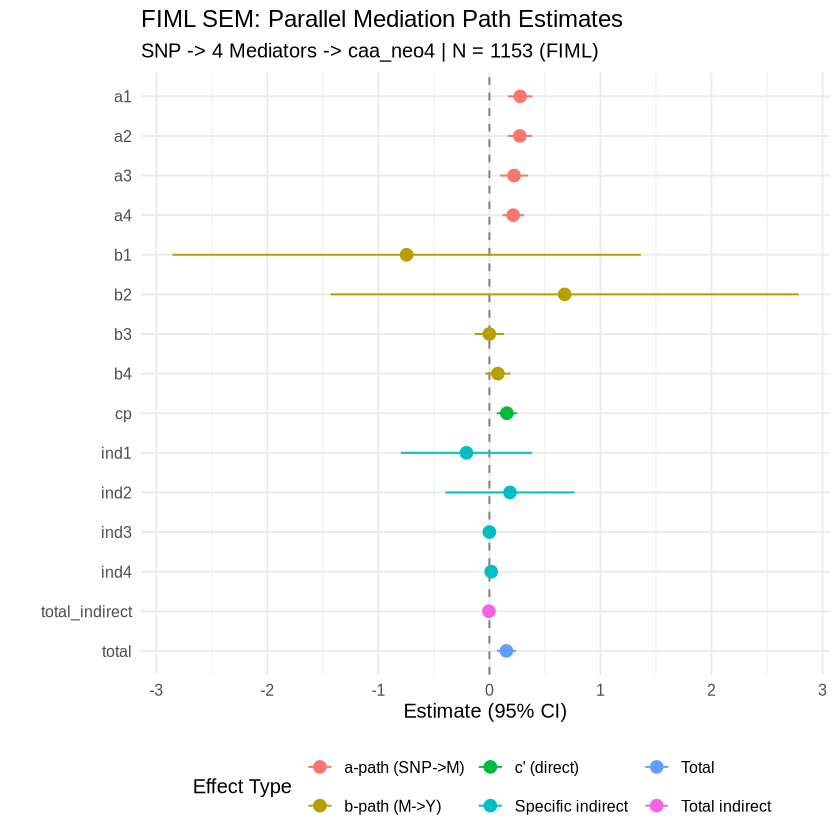

In [7]:
# ============================================================
# Section 5c: FIML -- Forest plot
# ============================================================

# Plot only main path estimates (a, b, cp, indirect, total)
plot_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                 paste0("ind", 1:n_med), "total_indirect", "total")
plot_df <- fiml_key[fiml_key$label %in% plot_labels, ]

# Create effect type grouping
plot_df$effect_type <- ifelse(grepl("^a", plot_df$label), "a-path (SNP->M)",
                       ifelse(grepl("^b", plot_df$label), "b-path (M->Y)",
                       ifelse(plot_df$label == "cp", "c' (direct)",
                       ifelse(grepl("^ind", plot_df$label), "Specific indirect",
                       ifelse(plot_df$label == "total_indirect", "Total indirect", "Total")))))

# Order labels
plot_df$label <- factor(plot_df$label, levels=rev(plot_labels))

p_fiml <- ggplot(plot_df, aes(x=est, y=label, xmin=ci.lower, xmax=ci.upper, color=effect_type)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(size=0.6) +
  labs(title="FIML SEM: Parallel Mediation Path Estimates",
       subtitle=paste0("SNP -> 4 Mediators -> caa_neo4 | N = ", N_fiml, " (FIML)"),
       x="Estimate (95% CI)", y="", color="Effect Type") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(RESULT_DIR, "main_SEM_FIML", "fiml_forest_plot.png"), p_fiml, width=10, height=8, dpi=150)
ggsave(file.path(RESULT_DIR, "main_SEM_FIML", "fiml_forest_plot.pdf"), p_fiml, width=10, height=8)
print(p_fiml)
cat("FIML forest plot saved.\n")

### FIML Interpretation

- **a-paths (a1--a4):** Effect of the SNP on each mediator (gene expression), controlling for mediator-specific covariates.
- **b-paths (b1--b4):** Effect of each mediator on caa_neo4, controlling for the SNP, all other mediators, and outcome covariates. These are **unique** effects (specific to each mediator after partialing out the others).
- **c' (direct):** Direct effect of SNP on caa_neo4, not mediated through any of the four expression mediators.
- **Specific indirect (ind1--ind4):** Unique mediation through each mediator = a_i x b_i.
- **Total indirect:** Sum of all specific indirect effects.
- **Total:** Direct + total indirect.
- **Contrasts (diff):** Differences between specific indirect effects -- tests whether one mediator carries more of the SNP effect than another.

## Method 2: Bootstrap (FIML inside each replicate)

Non-parametric bootstrap with FIML SEM inside each replicate provides percentile confidence intervals that do not assume normality of the indirect effect distribution. This is especially important for products of coefficients (a x b), which are typically non-normal.

In [8]:
# ============================================================
# Section 6: Bootstrap (FIML inside)
# ============================================================
set.seed(12345)
B <- 1000

# Parameters to extract
boot_params <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                 paste0("ind", 1:n_med), "total_indirect", "total")
boot_mat <- matrix(NA, B, length(boot_params), dimnames=list(NULL, boot_params))

cat("Running", B, "bootstrap replicates (FIML inside, N =", N_total, ")...\n")
n_converged <- 0

for (i in 1:B) {
  idx <- sample(nrow(dat), replace=TRUE)
  boot_dat <- dat[idx, ]
  fit_b <- tryCatch(
    sem(model_str, data=boot_dat, missing="fiml", fixed.x=FALSE, se="none", test="none"),
    error = function(e) NULL,
    warning = function(w) {
      tryCatch(sem(model_str, data=boot_dat, missing="fiml", fixed.x=FALSE, se="none", test="none"),
               error = function(e) NULL)
    }
  )
  if (!is.null(fit_b) && lavInspect(fit_b, "converged")) {
    pe_b <- parameterEstimates(fit_b)
    for (lab in boot_params) {
      row_b <- pe_b[pe_b$label == lab, ]
      if (nrow(row_b) == 1) boot_mat[i, lab] <- row_b$est
    }
    n_converged <- n_converged + 1
  }
  if (i %% 200 == 0) cat("  Replicate", i, "/", B, "-- converged so far:", n_converged, "\n")
}

cat("\nBootstrap complete:", n_converged, "/", B, "replicates converged.\n")

Running 1000 bootstrap replicates (FIML inside, N = 1153 )...


  Replicate 200 / 1000 -- converged so far: 200 
  Replicate 400 / 1000 -- converged so far: 400 
  Replicate 600 / 1000 -- converged so far: 600 
  Replicate 800 / 1000 -- converged so far: 800 
  Replicate 1000 / 1000 -- converged so far: 1000 



Bootstrap complete: 1000 / 1000 replicates converged.


In [9]:
# ============================================================
# Section 6b: Bootstrap -- Summarize results
# ============================================================
boot_summary <- data.frame(
  label = boot_params,
  mean = apply(boot_mat, 2, mean, na.rm=TRUE),
  se = apply(boot_mat, 2, sd, na.rm=TRUE),
  ci_lower = apply(boot_mat, 2, quantile, 0.025, na.rm=TRUE),
  ci_upper = apply(boot_mat, 2, quantile, 0.975, na.rm=TRUE),
  stringsAsFactors=FALSE
)

# Two-sided p-value
boot_summary$p_value <- sapply(boot_params, function(lab) {
  vals <- boot_mat[, lab]
  vals <- vals[!is.na(vals)]
  if (length(vals) < 10) return(NA)
  p_pos <- mean(vals > 0)
  2 * min(p_pos, 1 - p_pos)
})

boot_summary$method <- "Bootstrap"
boot_summary$N <- N_total
boot_summary$n_converged <- n_converged
boot_summary$exposure <- EXPOSURE
boot_summary$direction <- "D1"

write.csv(boot_summary, file.path(RESULT_DIR, "bootstrap", "bootstrap_results.csv"), row.names=FALSE)

cat("\n=== Bootstrap Results (N =", N_total, ",", n_converged, "converged) ===\n")
print(boot_summary[, c("label", "mean", "se", "ci_lower", "ci_upper", "p_value")])


=== Bootstrap Results (N = 1153 , 1000 converged) ===


                        label          mean         se    ci_lower   ci_upper
a1                         a1  2.756692e-01 0.05593749  0.16838188 0.38664891
a2                         a2  2.724379e-01 0.05619779  0.16523781 0.38433166
a3                         a3  2.202297e-01 0.05994844  0.10674124 0.34372846
a4                         a4  2.138515e-01 0.04478890  0.12808918 0.30368012
b1                         b1 -7.761264e-01 1.03020784 -2.86437646 1.21334986
b2                         b2  7.090556e-01 1.03182314 -1.27844398 2.71977129
b3                         b3 -5.665145e-04 0.07625530 -0.14828303 0.14880943
b4                         b4  7.538936e-02 0.06439572 -0.05999745 0.19766965
cp                         cp  1.592343e-01 0.04582395  0.06892625 0.24500729
ind1                     ind1 -2.159513e-01 0.29241791 -0.84021532 0.33459744
ind2                     ind2  1.949332e-01 0.28894742 -0.33700796 0.81291554
ind3                     ind3  1.134098e-05 0.01746445 -0.035143

Bootstrap distribution plots saved.


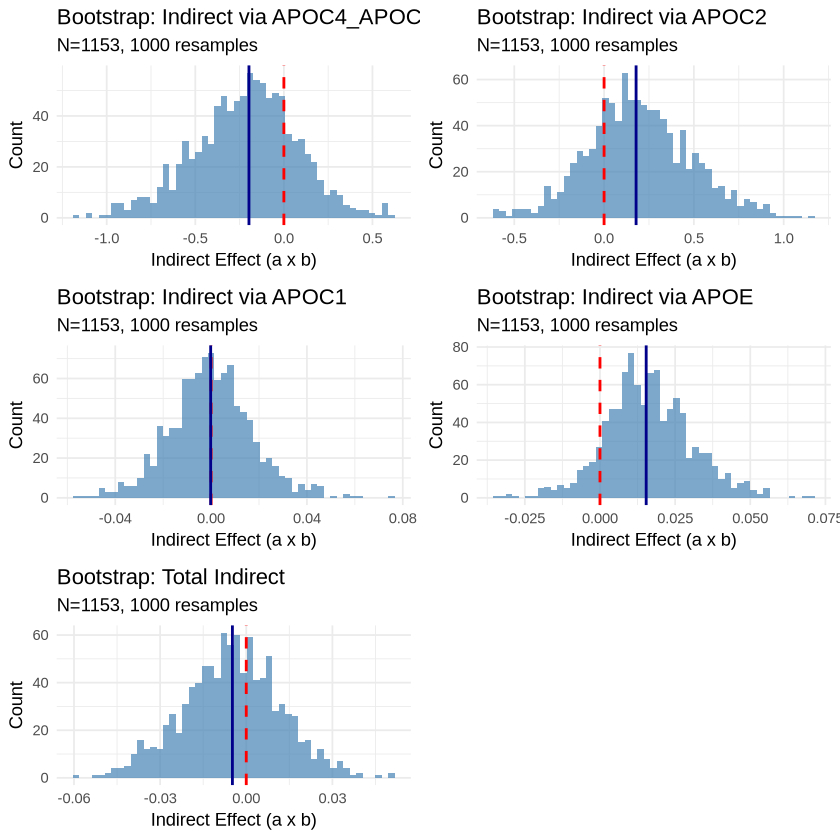

In [10]:
# ============================================================
# Section 6c: Bootstrap -- Distribution histograms
# ============================================================
ind_labels <- c(paste0("ind", 1:n_med), "total_indirect")
ind_names <- c(paste0("Indirect via ", MEDIATOR_SHORT), "Total Indirect")

plots_boot <- list()
for (k in seq_along(ind_labels)) {
  lab <- ind_labels[k]
  vals <- boot_mat[, lab]
  vals <- vals[!is.na(vals)]
  df_h <- data.frame(value=vals)
  med_val <- median(vals)

  p_h <- ggplot(df_h, aes(x=value)) +
    geom_histogram(bins=50, fill="steelblue", alpha=0.7) +
    geom_vline(xintercept=0, linetype="dashed", color="red", linewidth=0.8) +
    geom_vline(xintercept=med_val, linetype="solid", color="darkblue", linewidth=0.8) +
    labs(title=paste0("Bootstrap: ", ind_names[k]),
         subtitle=paste0("N=", N_total, ", ", n_converged, " resamples"),
         x="Indirect Effect (a x b)", y="Count") +
    theme_minimal(base_size=11)
  plots_boot[[k]] <- p_h
}

p_boot_all <- do.call(gridExtra::grid.arrange, c(plots_boot, ncol=2))

ggsave(file.path(RESULT_DIR, "bootstrap", paste0("bootstrap_distributions_", EXPOSURE, ".png")),
       p_boot_all, width=12, height=10, dpi=150)
ggsave(file.path(RESULT_DIR, "bootstrap", paste0("bootstrap_distributions_", EXPOSURE, ".pdf")),
       p_boot_all, width=12, height=10)
cat("Bootstrap distribution plots saved.\n")

Bootstrap forest plot saved.


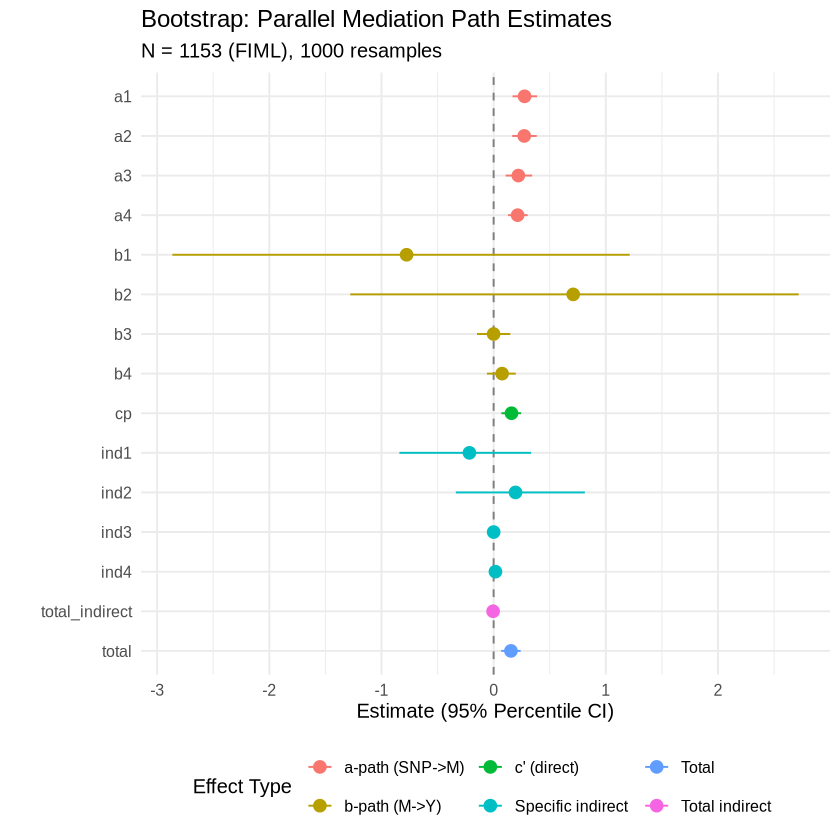

In [11]:
# ============================================================
# Section 6d: Bootstrap -- Forest plot
# ============================================================
boot_plot_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                      paste0("ind", 1:n_med), "total_indirect", "total")
boot_plot_df <- boot_summary[boot_summary$label %in% boot_plot_labels, ]
boot_plot_df$effect_type <- ifelse(grepl("^a", boot_plot_df$label), "a-path (SNP->M)",
                            ifelse(grepl("^b", boot_plot_df$label), "b-path (M->Y)",
                            ifelse(boot_plot_df$label == "cp", "c' (direct)",
                            ifelse(grepl("^ind", boot_plot_df$label), "Specific indirect",
                            ifelse(boot_plot_df$label == "total_indirect", "Total indirect", "Total")))))

boot_plot_df$label <- factor(boot_plot_df$label, levels=rev(boot_plot_labels))

p_boot_forest <- ggplot(boot_plot_df, aes(x=mean, y=label, xmin=ci_lower, xmax=ci_upper, color=effect_type)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(size=0.6) +
  labs(title="Bootstrap: Parallel Mediation Path Estimates",
       subtitle=paste0("N = ", N_total, " (FIML), ", n_converged, " resamples"),
       x="Estimate (95% Percentile CI)", y="", color="Effect Type") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(RESULT_DIR, "bootstrap", "bootstrap_forest_plot.png"), p_boot_forest, width=10, height=8, dpi=150)
ggsave(file.path(RESULT_DIR, "bootstrap", "bootstrap_forest_plot.pdf"), p_boot_forest, width=10, height=8)
print(p_boot_forest)
cat("Bootstrap forest plot saved.\n")

### Bootstrap Interpretation

The bootstrap provides non-parametric percentile confidence intervals for all path estimates. Because the indirect effect (a x b) is a product of two coefficients, its sampling distribution is typically non-normal and right-skewed, making bootstrap CIs more appropriate than Wald-based CIs.

If a specific indirect effect's 95% CI excludes zero, it provides evidence that the corresponding mediator uniquely transmits the SNP effect to caa_neo4, even after controlling for the other three mediators.

## Method 3: MNAR Sensitivity Analysis

The MNAR sensitivity analysis tests how robust the mediation findings are to violations of the Missing At Random (MAR) assumption. We systematically shift the imputed values for missing mediators and outcomes by delta (in SD units) and refit the SEM to see if/when the indirect effects become non-significant.

In [12]:
# ============================================================
# Section 7: MNAR Sensitivity Analysis
# ============================================================
delta_range <- seq(-3, 3, length.out=15)
grid <- expand.grid(delta_med=delta_range, delta_out=delta_range)

# Pre-compute means and SDs for mediators and outcome
med_stats <- lapply(MEDIATORS, function(m) {
  list(mean=mean(dat[[m]], na.rm=TRUE), sd=sd(dat[[m]], na.rm=TRUE))
})
names(med_stats) <- MEDIATORS
out_mean <- mean(dat[[OUTCOME]], na.rm=TRUE)
out_sd <- sd(dat[[OUTCOME]], na.rm=TRUE)

# Store results for each specific indirect + total indirect
mnar_labels <- c(paste0("ind", 1:n_med), "total_indirect")
mnar_est <- matrix(NA, nrow(grid), length(mnar_labels), dimnames=list(NULL, mnar_labels))
mnar_pval <- matrix(NA, nrow(grid), length(mnar_labels), dimnames=list(NULL, mnar_labels))

cat("Running MNAR sensitivity (", nrow(grid), "grid points, N =", N_total, ")...\n")

for (k in 1:nrow(grid)) {
  dat_imp <- dat
  # Delta-shift mediators
  for (m in MEDIATORS) {
    miss_idx <- is.na(dat_imp[[m]])
    dat_imp[[m]][miss_idx] <- med_stats[[m]]$mean + grid$delta_med[k] * med_stats[[m]]$sd
  }
  # Delta-shift outcome
  miss_y <- is.na(dat_imp[[OUTCOME]])
  dat_imp[[OUTCOME]][miss_y] <- out_mean + grid$delta_out[k] * out_sd
  # Impute missing covariates with means
  for (cov in ALL_COVS) {
    miss_c <- is.na(dat_imp[[cov]])
    if (any(miss_c)) dat_imp[[cov]][miss_c] <- mean(dat_imp[[cov]], na.rm=TRUE)
  }

  fit_m <- tryCatch(
    sem(model_str, data=dat_imp, estimator="ML", fixed.x=FALSE),
    error = function(e) NULL
  )

  if (!is.null(fit_m) && lavInspect(fit_m, "converged")) {
    pe_m <- parameterEstimates(fit_m)
    for (lab in mnar_labels) {
      row_m <- pe_m[pe_m$label == lab, ]
      if (nrow(row_m) == 1) {
        mnar_est[k, lab] <- row_m$est
        mnar_pval[k, lab] <- row_m$pvalue
      }
    }
  }
  if (k %% 50 == 0) cat("  Grid point", k, "/", nrow(grid), "\n")
}

cat("MNAR sensitivity complete.\n")

Running MNAR sensitivity ( 225 grid points, N = 1153 )...


  Grid point 50 / 225 
  Grid point 100 / 225 
  Grid point 150 / 225 
  Grid point 200 / 225 


MNAR sensitivity complete.


In [13]:
# ============================================================
# Section 7b: MNAR -- Save grid results and compute tipping points
# ============================================================
mnar_grid <- cbind(grid, mnar_est, mnar_pval)
# Rename p-value columns
n_est <- ncol(grid) + length(mnar_labels)
colnames(mnar_grid)[(n_est + 1):ncol(mnar_grid)] <- paste0("p_", mnar_labels)
mnar_grid$N <- N_total
mnar_grid$exposure <- EXPOSURE

write.csv(mnar_grid, file.path(RESULT_DIR, "MNAR_sensitivity", "mnar_grid_results.csv"), row.names=FALSE)

# Tipping points: minimum Euclidean distance from (0,0) where result becomes NS (p > 0.05)
tipping <- data.frame(label=mnar_labels, tipping_dist=NA, tipping_delta_med=NA, tipping_delta_out=NA,
                      stringsAsFactors=FALSE)

for (j in seq_along(mnar_labels)) {
  lab <- mnar_labels[j]
  p_col <- paste0("p_", lab)
  ns_idx <- which(mnar_grid[[p_col]] > 0.05)
  if (length(ns_idx) > 0) {
    dists <- sqrt(mnar_grid$delta_med[ns_idx]^2 + mnar_grid$delta_out[ns_idx]^2)
    min_i <- ns_idx[which.min(dists)]
    tipping$tipping_dist[j] <- min(dists)
    tipping$tipping_delta_med[j] <- mnar_grid$delta_med[min_i]
    tipping$tipping_delta_out[j] <- mnar_grid$delta_out[min_i]
  }
}
tipping$N <- N_total
tipping$exposure <- EXPOSURE

write.csv(tipping, file.path(RESULT_DIR, "MNAR_sensitivity", "mnar_tipping_summary.csv"), row.names=FALSE)

cat("\n=== MNAR Tipping Points ===\n")
print(tipping)


=== MNAR Tipping Points ===


           label tipping_dist tipping_delta_med tipping_delta_out    N
1           ind1            0                 0                 0 1153
2           ind2            0                 0                 0 1153
3           ind3            0                 0                 0 1153
4           ind4            0                 0                 0 1153
5 total_indirect            0                 0                 0 1153
            exposure
1 chr19_44954310_T_C
2 chr19_44954310_T_C
3 chr19_44954310_T_C
4 chr19_44954310_T_C
5 chr19_44954310_T_C


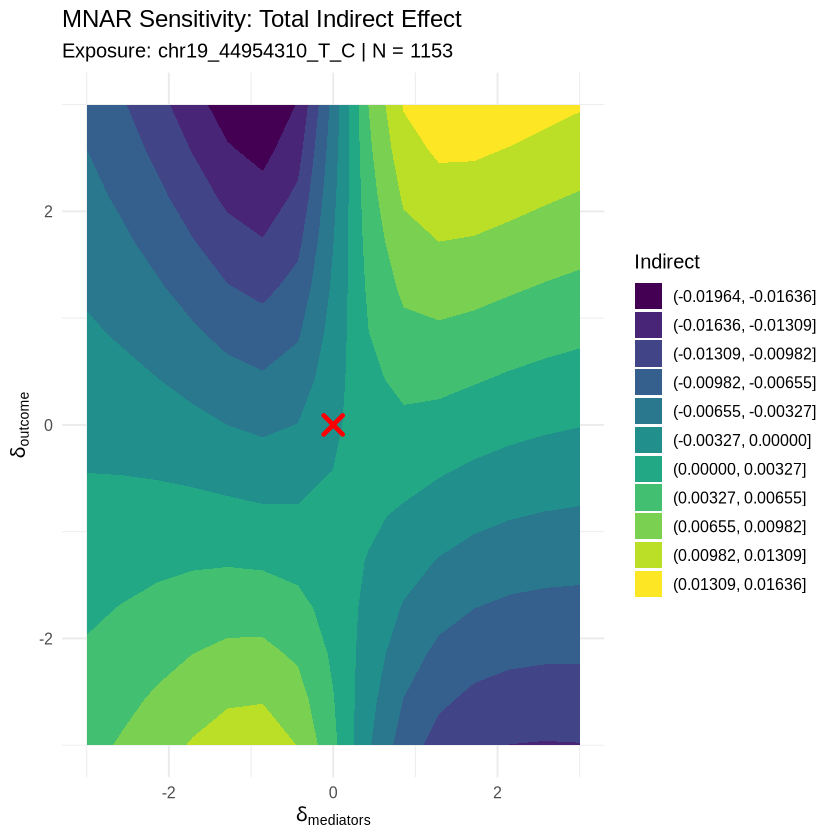

MNAR contour plots saved.


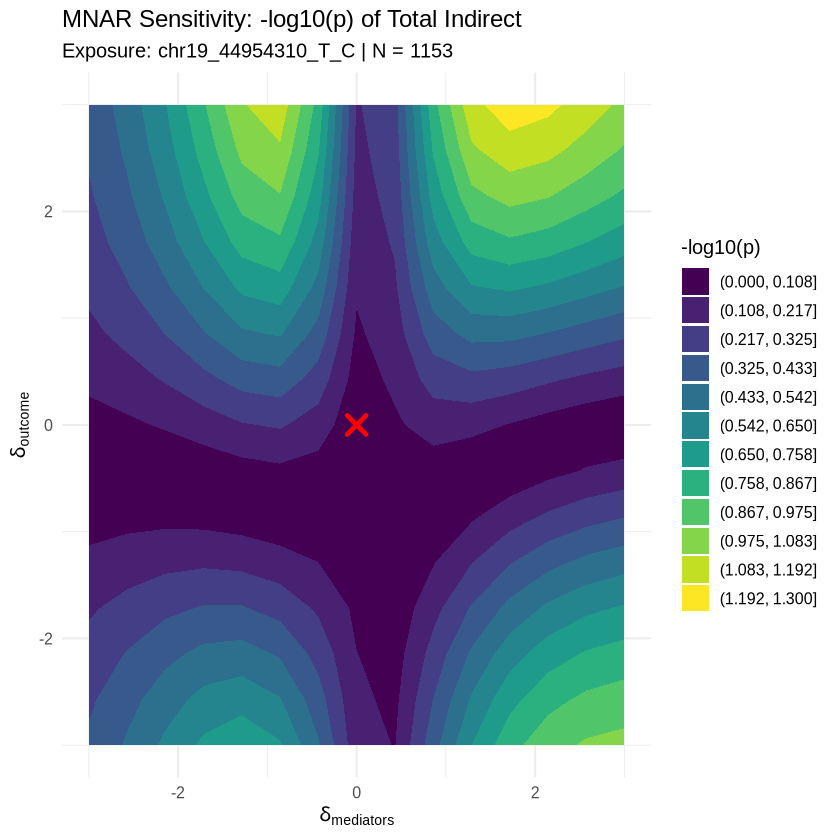

In [14]:
# ============================================================
# Section 7c: MNAR -- Contour plots
# ============================================================
# Total indirect contour
mnar_plot_df <- data.frame(
  delta_med = grid$delta_med,
  delta_out = grid$delta_out,
  indirect = mnar_est[, "total_indirect"],
  neg_log_p = -log10(mnar_pval[, "total_indirect"] + 1e-16)
)
mnar_plot_df <- mnar_plot_df[complete.cases(mnar_plot_df), ]

# Indirect effect contour
p_contour_ind <- ggplot(mnar_plot_df, aes(x=delta_med, y=delta_out, z=indirect)) +
  geom_contour_filled(bins=12) +
  scale_fill_viridis_d(option="viridis") +
  annotate("point", x=0, y=0, shape=4, size=4, color="red", stroke=2) +
  labs(title="MNAR Sensitivity: Total Indirect Effect",
       subtitle=paste0("Exposure: ", EXPOSURE, " | N = ", N_total),
       x=expression(delta[mediators]), y=expression(delta[outcome]), fill="Indirect") +
  theme_minimal(base_size=12)

ggsave(file.path(RESULT_DIR, "MNAR_sensitivity", paste0("mnar_contour_indirect_", EXPOSURE, ".png")),
       p_contour_ind, width=8, height=7, dpi=150)
ggsave(file.path(RESULT_DIR, "MNAR_sensitivity", paste0("mnar_contour_indirect_", EXPOSURE, ".pdf")),
       p_contour_ind, width=8, height=7)
print(p_contour_ind)

# P-value contour
p_contour_p <- ggplot(mnar_plot_df, aes(x=delta_med, y=delta_out, z=neg_log_p)) +
  geom_contour_filled(bins=12) +
  scale_fill_viridis_d(option="viridis") +
  annotate("point", x=0, y=0, shape=4, size=4, color="red", stroke=2) +
  labs(title="MNAR Sensitivity: -log10(p) of Total Indirect",
       subtitle=paste0("Exposure: ", EXPOSURE, " | N = ", N_total),
       x=expression(delta[mediators]), y=expression(delta[outcome]), fill="-log10(p)") +
  theme_minimal(base_size=12)

ggsave(file.path(RESULT_DIR, "MNAR_sensitivity", paste0("mnar_contour_pvalue_", EXPOSURE, ".png")),
       p_contour_p, width=8, height=7, dpi=150)
ggsave(file.path(RESULT_DIR, "MNAR_sensitivity", paste0("mnar_contour_pvalue_", EXPOSURE, ".pdf")),
       p_contour_p, width=8, height=7)
print(p_contour_p)

cat("MNAR contour plots saved.\n")

MNAR 1D slice plots saved.


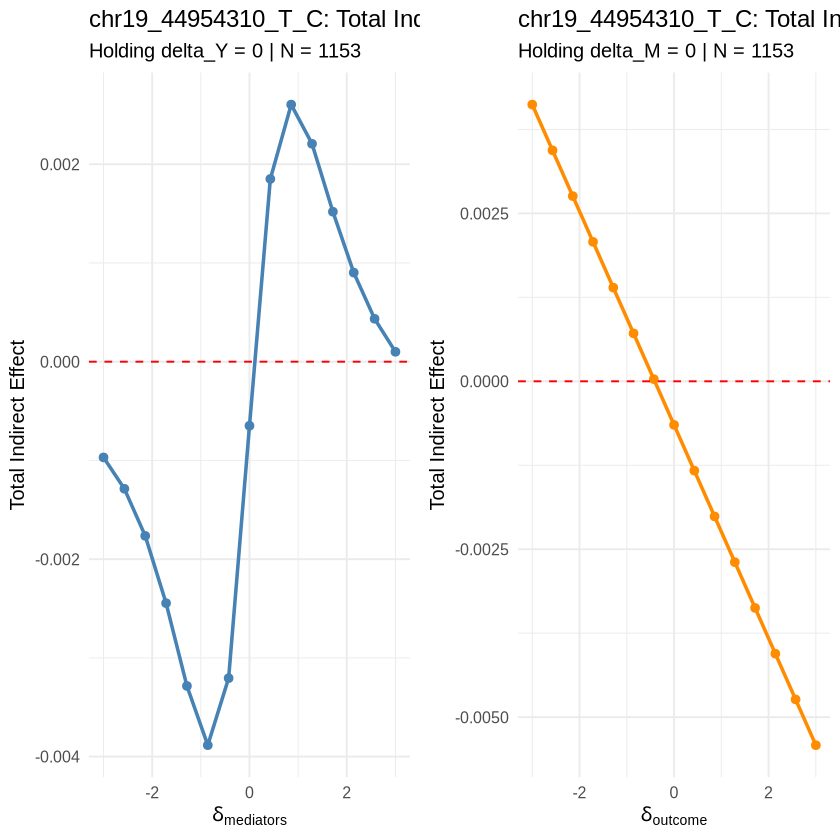

In [15]:
# ============================================================
# Section 7d: MNAR -- 1D slice plots
# ============================================================
closest_zero <- delta_range[which.min(abs(delta_range))]

slice_med <- mnar_grid[abs(mnar_grid$delta_out - closest_zero) < 0.01, ]
slice_out <- mnar_grid[abs(mnar_grid$delta_med - closest_zero) < 0.01, ]

p_slice1 <- ggplot(slice_med, aes(x=delta_med, y=total_indirect)) +
  geom_line(color="steelblue", linewidth=1) +
  geom_point(color="steelblue", size=2) +
  geom_hline(yintercept=0, linetype="dashed", color="red") +
  labs(title=paste0(EXPOSURE, ": Total Indirect vs delta_M"),
       subtitle=paste0("Holding delta_Y = 0 | N = ", N_total),
       x=expression(delta[mediators]), y="Total Indirect Effect") +
  theme_minimal(base_size=12)

p_slice2 <- ggplot(slice_out, aes(x=delta_out, y=total_indirect)) +
  geom_line(color="darkorange", linewidth=1) +
  geom_point(color="darkorange", size=2) +
  geom_hline(yintercept=0, linetype="dashed", color="red") +
  labs(title=paste0(EXPOSURE, ": Total Indirect vs delta_Y"),
       subtitle=paste0("Holding delta_M = 0 | N = ", N_total),
       x=expression(delta[outcome]), y="Total Indirect Effect") +
  theme_minimal(base_size=12)

p_slices <- gridExtra::grid.arrange(p_slice1, p_slice2, ncol=2)

ggsave(file.path(RESULT_DIR, "MNAR_sensitivity", paste0("mnar_1d_slices_", EXPOSURE, ".png")),
       p_slices, width=12, height=5, dpi=150)
ggsave(file.path(RESULT_DIR, "MNAR_sensitivity", paste0("mnar_1d_slices_", EXPOSURE, ".pdf")),
       p_slices, width=12, height=5)
cat("MNAR 1D slice plots saved.\n")

### MNAR Interpretation

The contour plots show how the total indirect effect and its significance change as we shift imputed values for missing mediators (x-axis) and outcome (y-axis) by delta SD units. The red X marks the MAR reference point (delta=0,0). A tipping point is the closest grid point to (0,0) where significance is lost -- larger distances indicate more robust findings.

## Method 4: Bayesian SEM (blavaan/Stan)

Bayesian SEM provides posterior distributions for all parameters, allowing direct probability statements (e.g., P(indirect > 0)). blavaan handles missing data automatically through Stan's data augmentation. This avoids the normality assumption for indirect effect inference.

In [16]:
# ============================================================
# Section 8: Bayesian SEM (blavaan)
# ============================================================
cat("Fitting Bayesian SEM (blavaan, N =", N_total, ")...\n")
cat("Using 4 chains x 2000 samples (1000 burnin).\n")

fit_bayes <- tryCatch(
  bsem(model_str, data=dat, fixed.x=FALSE, target="stan",
       n.chains=4, burnin=1000, sample=2000, seed=42),
  error = function(e) {
    cat("blavaan error:", conditionMessage(e), "\n")
    cat("Trying with 2 chains...\n")
    tryCatch(
      bsem(model_str, data=dat, fixed.x=FALSE, target="stan",
           n.chains=2, burnin=1000, sample=2000, seed=42),
      error = function(e2) { cat("blavaan 2-chain error:", conditionMessage(e2), "\n"); NULL }
    )
  }
)

if (!is.null(fit_bayes)) {
  cat("Bayesian SEM fitted successfully.\n")
  summary(fit_bayes)
} else {
  cat("WARNING: Bayesian SEM failed. Will be excluded from summary.\n")
}

Fitting Bayesian SEM (blavaan, N = 1153 )...


Using 4 chains x 2000 samples (1000 burnin).



SAMPLING FOR MODEL 'stanmarg' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.00492 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 49.2 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 3000 [  0%]  (Warmup)
Chain 1: Iteration:  300 / 3000 [ 10%]  (Warmup)
Chain 1: Iteration:  600 / 3000 [ 20%]  (Warmup)
Chain 1: Iteration:  900 / 3000 [ 30%]  (Warmup)
Chain 1: Iteration: 1001 / 3000 [ 33%]  (Sampling)
Chain 1: Iteration: 1300 / 3000 [ 43%]  (Sampling)
Chain 1: Iteration: 1600 / 3000 [ 53%]  (Sampling)
Chain 1: Iteration: 1900 / 3000 [ 63%]  (Sampling)
Chain 1: Iteration: 2200 / 3000 [ 73%]  (Sampling)
Chain 1: Iteration: 2500 / 3000 [ 83%]  (Sampling)
Chain 1: Iteration: 2800 / 3000 [ 93%]  (Sampling)
Chain 1: Iteration: 3000 / 3000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1731.44 seconds (Warm-up)
Chain 1:                3987.32 seconds (Sampling)
Chain 1:              

Warning message:
“There were 8000 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded”


Warning message:
“Examine the pairs() plot to diagnose sampling problems
”


Warning message:
“Bulk Effective Samples Size (ESS) is too low, indicating posterior means and medians may be unreliable.
Running the chains for more iterations may help. See
https://mc-stan.org/misc/warnings.html#bulk-ess”


Computing post-estimation metrics (including lvs if requested)...


Bayesian SEM fitted successfully.
blavaan 0.5.10 ended normally after 2000 iterations

  Estimator                                      BAYES
  Optimization method                             MCMC
  Number of model parameters                        78

  Number of observations                          1153
  Number of missing patterns                        24

  Statistic                                 MargLogLik         PPP
  Value                                             NA       0.372

Parameter Estimates:


Regressions:
                          Estimate  Post.SD pi.lower pi.upper     Rhat
  APOC4_APOC2_AC_exp ~                                                
    c19_44954 (a1)           0.280    0.058    0.164    0.391    1.012
    msex_u                   0.096    0.082   -0.061    0.256    1.014
    age_deth_                0.023    0.006    0.011    0.035    1.009
    pmi_u                    0.012    0.008   -0.004    0.026    1.006
    ROS_stdy_               -0.161    0

In [17]:
# ============================================================
# Section 8b: Bayesian -- Extract results
# ============================================================
bayes_results <- NULL

if (!is.null(fit_bayes)) {
  pt <- parTable(fit_bayes)
  labeled <- pt[pt$label != "", ]

  # Get posterior draws
  draws_list <- blavInspect(fit_bayes, "mcmc")
  draws <- do.call(rbind, draws_list)

  draw_cols <- colnames(draws)
  cat("Available draw columns (first 30):", head(draw_cols, 30), "\n")

  # Extract results for all labeled parameters
  bayes_rows <- list()
  target_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                     paste0("ind", 1:n_med), "total_indirect", "total")

  for (lab in target_labels) {
    pt_row <- labeled[labeled$label == lab, ]
    if (nrow(pt_row) == 0) next

    draw_col <- NULL
    if (lab %in% draw_cols) {
      draw_col <- lab
    } else {
      plabel <- pt_row$plabel[1]
      if (!is.na(plabel) && plabel %in% draw_cols) draw_col <- plabel
    }

    if (!is.null(draw_col)) {
      vals <- draws[, draw_col]
      bayes_rows[[lab]] <- data.frame(
        label = lab,
        mean = mean(vals),
        sd = sd(vals),
        ci_lower = as.numeric(quantile(vals, 0.025)),
        ci_upper = as.numeric(quantile(vals, 0.975)),
        p_direction = max(mean(vals > 0), mean(vals < 0)),
        stringsAsFactors = FALSE
      )
    } else {
      bayes_rows[[lab]] <- data.frame(
        label = lab,
        mean = pt_row$est[1],
        sd = pt_row$se[1],
        ci_lower = pt_row$est[1] - 1.96*pt_row$se[1],
        ci_upper = pt_row$est[1] + 1.96*pt_row$se[1],
        p_direction = NA,
        stringsAsFactors = FALSE
      )
    }
  }

  bayes_results <- do.call(rbind, bayes_rows)
  rownames(bayes_results) <- NULL
  bayes_results$method <- "Bayesian"
  bayes_results$N <- N_total
  bayes_results$exposure <- EXPOSURE
  bayes_results$direction <- "D1"

  write.csv(bayes_results, file.path(RESULT_DIR, "bayesian_blavaan", "bayesian_results.csv"), row.names=FALSE)

  cat("\n=== Bayesian Results (N =", N_total, ") ===\n")
  print(bayes_results[, c("label", "mean", "sd", "ci_lower", "ci_upper", "p_direction")])
}

Available draw columns (first 30): a1 APOC4_APOC2_AC_exp~msex_u APOC4_APOC2_AC_exp~age_death_u APOC4_APOC2_AC_exp~pmi_u APOC4_APOC2_AC_exp~ROS_study_u a2 APOC2_AC_exp~msex_u APOC2_AC_exp~age_death_u APOC2_AC_exp~pmi_u APOC2_AC_exp~ROS_study_u a3 APOC1_DeJager_Mic_exp~msex_u APOC1_DeJager_Mic_exp~age_death_u APOC1_DeJager_Mic_exp~pmi_u a4 APOE_Mega_Mic_exp~msex_u APOE_Mega_Mic_exp~age_death_u APOE_Mega_Mic_exp~pmi_u b1 b2 b3 b4 cp caa_neo4~educ caa_neo4~apoe4_dose caa_neo4~msex_u caa_neo4~age_death_u APOC4_APOC2_AC_exp~~APOC2_AC_exp APOC4_APOC2_AC_exp~~APOC1_DeJager_Mic_exp APOC4_APOC2_AC_exp~~APOE_Mega_Mic_exp 

=== Bayesian Results (N = 1153 ) ===
            label         mean         sd     ci_lower   ci_upper p_direction
1              a1  0.279794522 0.05799678  0.163694476 0.39129488    1.000000
2              a2  0.276602914 0.05803717  0.160839135 0.38714444    1.000000
3              a3  0.222922328 0.06503787  0.093692397 0.35144142    0.999875
4              a4  0.213006300 

Bayesian posterior density plots saved.


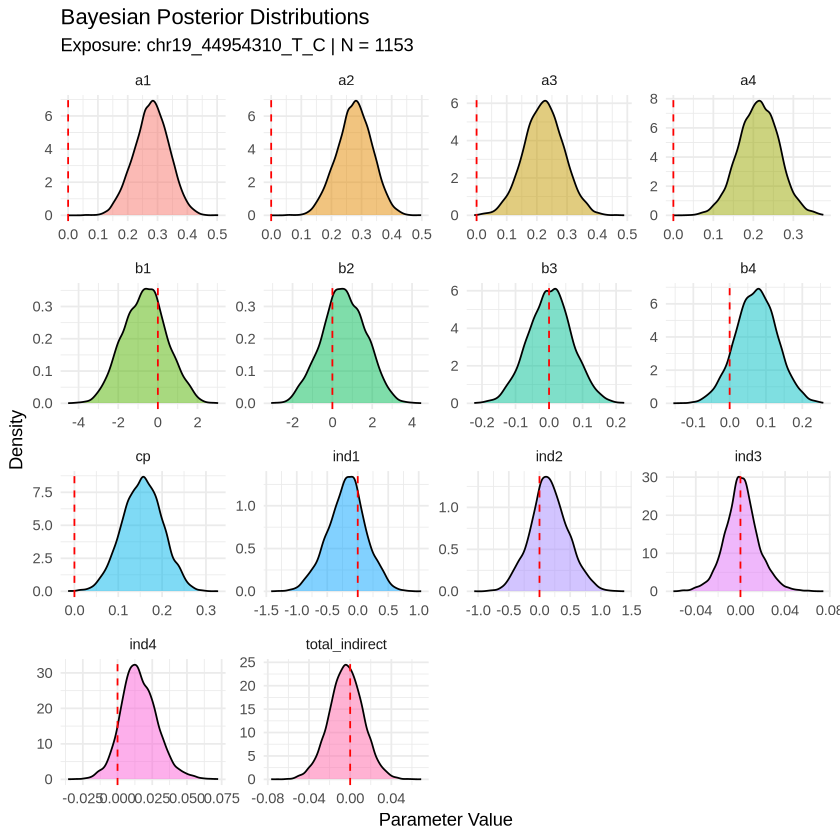

In [18]:
# ============================================================
# Section 8c: Bayesian -- Posterior density plots
# ============================================================
if (!is.null(fit_bayes)) {
  draws_list <- blavInspect(fit_bayes, "mcmc")
  draws <- do.call(rbind, draws_list)
  draw_cols <- colnames(draws)

  pt <- parTable(fit_bayes)
  labeled <- pt[pt$label != "", ]

  plot_params <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                   paste0("ind", 1:n_med), "total_indirect")

  dens_data <- list()
  for (lab in plot_params) {
    col_name <- NULL
    if (lab %in% draw_cols) {
      col_name <- lab
    } else {
      pt_row <- labeled[labeled$label == lab, ]
      if (nrow(pt_row) > 0 && !is.na(pt_row$plabel[1]) && pt_row$plabel[1] %in% draw_cols) {
        col_name <- pt_row$plabel[1]
      }
    }
    if (!is.null(col_name)) {
      dens_data[[length(dens_data)+1]] <- data.frame(
        parameter = lab, value = draws[, col_name]
      )
    }
  }

  if (length(dens_data) > 0) {
    dens_df <- do.call(rbind, dens_data)

    p_dens <- ggplot(dens_df, aes(x=value, fill=parameter)) +
      geom_density(alpha=0.5) +
      geom_vline(xintercept=0, linetype="dashed", color="red") +
      facet_wrap(~parameter, scales="free", ncol=4) +
      labs(title="Bayesian Posterior Distributions",
           subtitle=paste0("Exposure: ", EXPOSURE, " | N = ", N_total),
           x="Parameter Value", y="Density") +
      theme_minimal(base_size=11) +
      theme(legend.position="none")

    plot_h <- min(48, max(6, ceiling(length(plot_params)/4) * 3))
    ggsave(file.path(RESULT_DIR, "bayesian_blavaan", paste0("bayesian_posteriors_", EXPOSURE, ".png")),
           p_dens, width=14, height=plot_h, dpi=150, limitsize=FALSE)
    ggsave(file.path(RESULT_DIR, "bayesian_blavaan", paste0("bayesian_posteriors_", EXPOSURE, ".pdf")),
           p_dens, width=14, height=plot_h, limitsize=FALSE)
    print(p_dens)
    cat("Bayesian posterior density plots saved.\n")
  }
}

Bayesian trace plots saved.


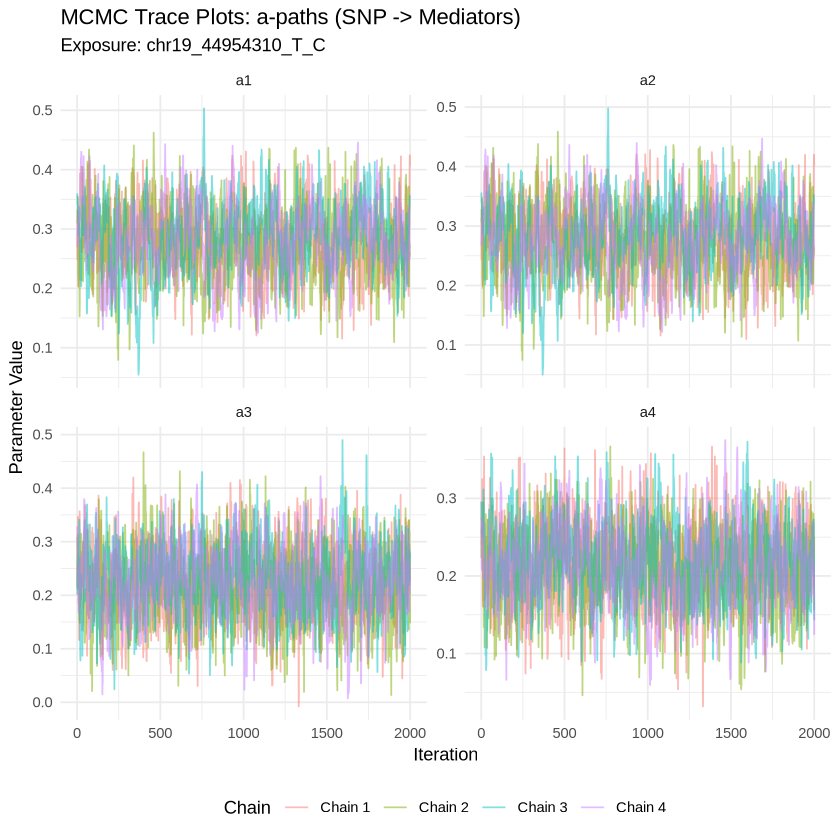

In [19]:
# ============================================================
# Section 8d: Bayesian -- Trace plot for a-paths
# ============================================================
if (!is.null(fit_bayes)) {
  draws_list <- blavInspect(fit_bayes, "mcmc")
  pt <- parTable(fit_bayes)
  labeled <- pt[pt$label != "", ]

  trace_data <- list()
  for (a_lab in paste0("a", 1:n_med)) {
    col_name <- NULL
    if (a_lab %in% colnames(draws_list[[1]])) {
      col_name <- a_lab
    } else {
      pt_row <- labeled[labeled$label == a_lab, ]
      if (nrow(pt_row) > 0 && !is.na(pt_row$plabel[1]) && pt_row$plabel[1] %in% colnames(draws_list[[1]])) {
        col_name <- pt_row$plabel[1]
      }
    }
    if (!is.null(col_name)) {
      for (ch in seq_along(draws_list)) {
        trace_data[[length(trace_data)+1]] <- data.frame(
          iteration = seq_len(nrow(draws_list[[ch]])),
          value = draws_list[[ch]][, col_name],
          chain = paste0("Chain ", ch),
          parameter = a_lab
        )
      }
    }
  }

  if (length(trace_data) > 0) {
    trace_df <- do.call(rbind, trace_data)

    p_trace <- ggplot(trace_df, aes(x=iteration, y=value, color=chain)) +
      geom_line(alpha=0.5) +
      facet_wrap(~parameter, scales="free_y", ncol=2) +
      labs(title="MCMC Trace Plots: a-paths (SNP -> Mediators)",
           subtitle=paste0("Exposure: ", EXPOSURE),
           x="Iteration", y="Parameter Value", color="Chain") +
      theme_minimal(base_size=11) +
      theme(legend.position="bottom")

    ggsave(file.path(RESULT_DIR, "bayesian_blavaan", paste0("bayesian_trace_a_", EXPOSURE, ".png")),
           p_trace, width=10, height=8, dpi=150)
    ggsave(file.path(RESULT_DIR, "bayesian_blavaan", paste0("bayesian_trace_a_", EXPOSURE, ".pdf")),
           p_trace, width=10, height=8)
    print(p_trace)
    cat("Bayesian trace plots saved.\n")
  }
}

Bayesian forest plot saved.


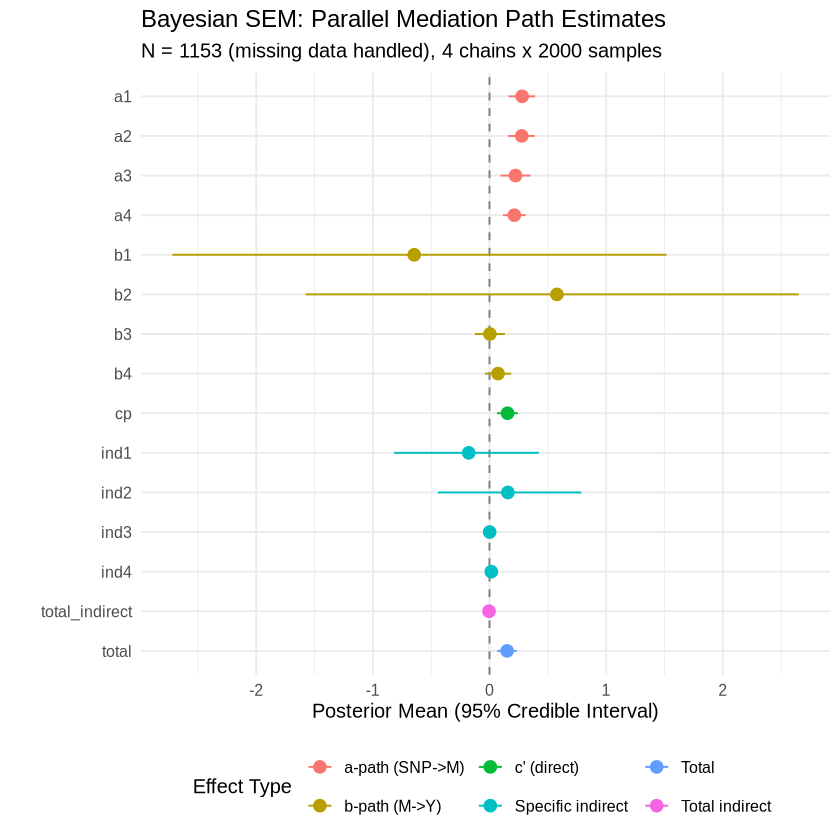

In [20]:
# ============================================================
# Section 8e: Bayesian -- Forest plot
# ============================================================
if (!is.null(bayes_results)) {
  bayes_plot_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                         paste0("ind", 1:n_med), "total_indirect", "total")
  bayes_plot_df <- bayes_results[bayes_results$label %in% bayes_plot_labels, ]

  bayes_plot_df$effect_type <- ifelse(grepl("^a", bayes_plot_df$label), "a-path (SNP->M)",
                               ifelse(grepl("^b", bayes_plot_df$label), "b-path (M->Y)",
                               ifelse(bayes_plot_df$label == "cp", "c' (direct)",
                               ifelse(grepl("^ind", bayes_plot_df$label), "Specific indirect",
                               ifelse(bayes_plot_df$label == "total_indirect", "Total indirect", "Total")))))

  bayes_plot_df$label <- factor(bayes_plot_df$label, levels=rev(bayes_plot_labels))

  n_chains <- length(blavInspect(fit_bayes, "mcmc"))
  n_samples <- nrow(blavInspect(fit_bayes, "mcmc")[[1]])

  p_bayes_forest <- ggplot(bayes_plot_df, aes(x=mean, y=label, xmin=ci_lower, xmax=ci_upper, color=effect_type)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(size=0.6) +
    labs(title="Bayesian SEM: Parallel Mediation Path Estimates",
         subtitle=paste0("N = ", N_total, " (missing data handled), ", n_chains, " chains x ", n_samples, " samples"),
         x="Posterior Mean (95% Credible Interval)", y="", color="Effect Type") +
    theme_minimal(base_size=12) +
    theme(legend.position="bottom")

  ggsave(file.path(RESULT_DIR, "bayesian_blavaan", "bayesian_forest_plot.png"), p_bayes_forest, width=10, height=8, dpi=150)
  ggsave(file.path(RESULT_DIR, "bayesian_blavaan", "bayesian_forest_plot.pdf"), p_bayes_forest, width=10, height=8)
  print(p_bayes_forest)
  cat("Bayesian forest plot saved.\n")
}

### Bayesian Interpretation

- **P(direction)**: The posterior probability that the parameter is on its dominant side of zero. Values close to 1.0 indicate strong directional evidence.
- **95% Credible Intervals**: There is a 95% posterior probability the true value falls within this range (a direct probability statement, unlike frequentist CIs).
- **Trace plots**: Good mixing means chains overlap and look like "hairy caterpillars." Poor mixing would indicate convergence problems.

## Cross-Method Summary

This section combines results from all methods (FIML, Bootstrap, Bayesian) into a single comparison table and visualization.

In [21]:
# ============================================================
# Section 9: Cross-Method Summary
# ============================================================

summary_rows <- list()

# FIML
for (i in 1:nrow(fiml_key)) {
  r <- fiml_key[i, ]
  summary_rows[[length(summary_rows)+1]] <- data.frame(
    exposure=EXPOSURE, direction="D1", method="FIML",
    label=r$label, est=r$est, se=r$se,
    ci_lower=r$ci.lower, ci_upper=r$ci.upper,
    pvalue=r$pvalue, ci_type="Wald",
    n_eff=paste0("N=", N_fiml, " (FIML)"),
    stringsAsFactors=FALSE
  )
}

# Bootstrap
for (i in 1:nrow(boot_summary)) {
  r <- boot_summary[i, ]
  summary_rows[[length(summary_rows)+1]] <- data.frame(
    exposure=EXPOSURE, direction="D1", method="Bootstrap",
    label=r$label, est=r$mean, se=r$se,
    ci_lower=r$ci_lower, ci_upper=r$ci_upper,
    pvalue=r$p_value, ci_type="Percentile",
    n_eff=paste0("N=", N_total, " (Bootstrap FIML, ", n_converged, " converged)"),
    stringsAsFactors=FALSE
  )
}

# Bayesian
if (!is.null(bayes_results)) {
  for (i in 1:nrow(bayes_results)) {
    r <- bayes_results[i, ]
    summary_rows[[length(summary_rows)+1]] <- data.frame(
      exposure=EXPOSURE, direction="D1", method="Bayesian",
      label=r$label, est=r$mean, se=r$sd,
      ci_lower=r$ci_lower, ci_upper=r$ci_upper,
      pvalue=NA, ci_type="95% CrI",
      n_eff=paste0("N=", N_total, " (Bayesian, fixed.x=FALSE)"),
      stringsAsFactors=FALSE
    )
  }
}

all_summary <- do.call(rbind, summary_rows)
rownames(all_summary) <- NULL

write.csv(all_summary, file.path(RESULT_DIR, "summary", "all_methods_summary.csv"), row.names=FALSE)

cat("\n=== All Methods Summary (Indirect Effects) ===\n")
ind_summary <- all_summary[all_summary$label %in% c(paste0("ind", 1:n_med), "total_indirect", "total"), ]
print(ind_summary[order(ind_summary$label, ind_summary$method),
                  c("method", "label", "est", "se", "ci_lower", "ci_upper", "pvalue", "n_eff")])


=== All Methods Summary (Indirect Effects) ===


      method          label           est         se     ci_lower   ci_upper
51  Bayesian           ind1 -1.781624e-01 0.31251364 -0.817896241 0.42426114
36 Bootstrap           ind1 -2.159513e-01 0.29241791 -0.840215322 0.33459744
10      FIML           ind1 -2.067000e-01 0.30144521 -0.797521730 0.38412178
52  Bayesian           ind2  1.575126e-01 0.30883184 -0.442516863 0.78693610
37 Bootstrap           ind2  1.949332e-01 0.28894742 -0.337007960 0.81291554
11      FIML           ind2  1.857000e-01 0.29727556 -0.396949382 0.76834941
53  Bayesian           ind3  1.130906e-03 0.01532019 -0.029447603 0.03339328
38 Bootstrap           ind3  1.134098e-05 0.01746445 -0.035143020 0.03790685
12      FIML           ind3 -1.703162e-04 0.01498653 -0.029543380 0.02920275
54  Bayesian           ind4  1.559692e-02 0.01310721 -0.008678276 0.04386078
39 Bootstrap           ind4  1.603124e-02 0.01455892 -0.013705054 0.04647205
13      FIML           ind4  1.638556e-02 0.01301868 -0.009130581 0.04190170

In [22]:
# ============================================================
# Section 9b: Display table (wide format)
# ============================================================
display_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                    paste0("ind", 1:n_med), "total_indirect", "total")

disp_sub <- all_summary[all_summary$label %in% display_labels, ]
disp_sub$formatted <- sprintf("%.4f [%.4f, %.4f]", disp_sub$est, disp_sub$ci_lower, disp_sub$ci_upper)

wide_df <- reshape2::dcast(disp_sub, label ~ method, value.var="formatted")
wide_df$label <- factor(wide_df$label, levels=display_labels)
wide_df <- wide_df[order(wide_df$label), ]

write.csv(wide_df, file.path(RESULT_DIR, "summary", paste0("summary_display_table_", EXPOSURE, ".csv")), row.names=FALSE)

cat("\n=== Wide-Format Display Table ===\n")
print(wide_df)


=== Wide-Format Display Table ===


            label                  Bayesian                 Bootstrap
1              a1   0.2798 [0.1637, 0.3913]   0.2757 [0.1684, 0.3866]
2              a2   0.2766 [0.1608, 0.3871]   0.2724 [0.1652, 0.3843]
3              a3   0.2229 [0.0937, 0.3514]   0.2202 [0.1067, 0.3437]
4              a4   0.2130 [0.1147, 0.3102]   0.2139 [0.1281, 0.3037]
5              b1 -0.6455 [-2.7192, 1.5171] -0.7761 [-2.8644, 1.2133]
6              b2  0.5783 [-1.5766, 2.6514]  0.7091 [-1.2784, 2.7198]
7              b3  0.0036 [-0.1251, 0.1318] -0.0006 [-0.1483, 0.1488]
8              b4  0.0732 [-0.0396, 0.1856]  0.0754 [-0.0600, 0.1977]
9              cp   0.1549 [0.0652, 0.2427]   0.1592 [0.0689, 0.2450]
10           ind1 -0.1782 [-0.8179, 0.4243] -0.2160 [-0.8402, 0.3346]
11           ind2  0.1575 [-0.4425, 0.7869]  0.1949 [-0.3370, 0.8129]
12           ind3  0.0011 [-0.0294, 0.0334]  0.0000 [-0.0351, 0.0379]
13           ind4  0.0156 [-0.0087, 0.0439]  0.0160 [-0.0137, 0.0465]
15 total_indirect -0

Summary forest plot saved.


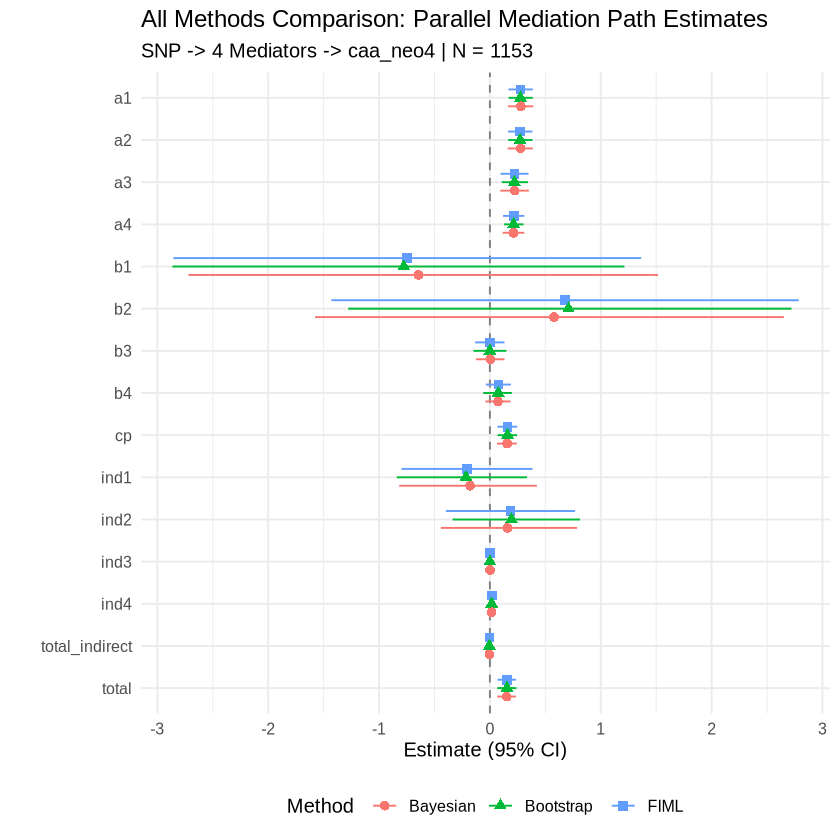

In [23]:
# ============================================================
# Section 9c: Summary Forest Plot -- All Methods
# ============================================================
plot_labels_summary <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                         paste0("ind", 1:n_med), "total_indirect", "total")
sum_plot <- all_summary[all_summary$label %in% plot_labels_summary, ]
sum_plot$label <- factor(sum_plot$label, levels=rev(plot_labels_summary))

p_sum_forest <- ggplot(sum_plot, aes(x=est, y=label, xmin=ci_lower, xmax=ci_upper,
                                     color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(position=position_dodge(width=0.6), size=0.5) +
  labs(title="All Methods Comparison: Parallel Mediation Path Estimates",
       subtitle=paste0("SNP -> 4 Mediators -> caa_neo4 | N = ", N_total),
       x="Estimate (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(RESULT_DIR, "summary", "summary_forest_all_methods.png"), p_sum_forest, width=11, height=9, dpi=150)
ggsave(file.path(RESULT_DIR, "summary", "summary_forest_all_methods.pdf"), p_sum_forest, width=11, height=9)
print(p_sum_forest)
cat("Summary forest plot saved.\n")

Faceted-by-path plot saved.


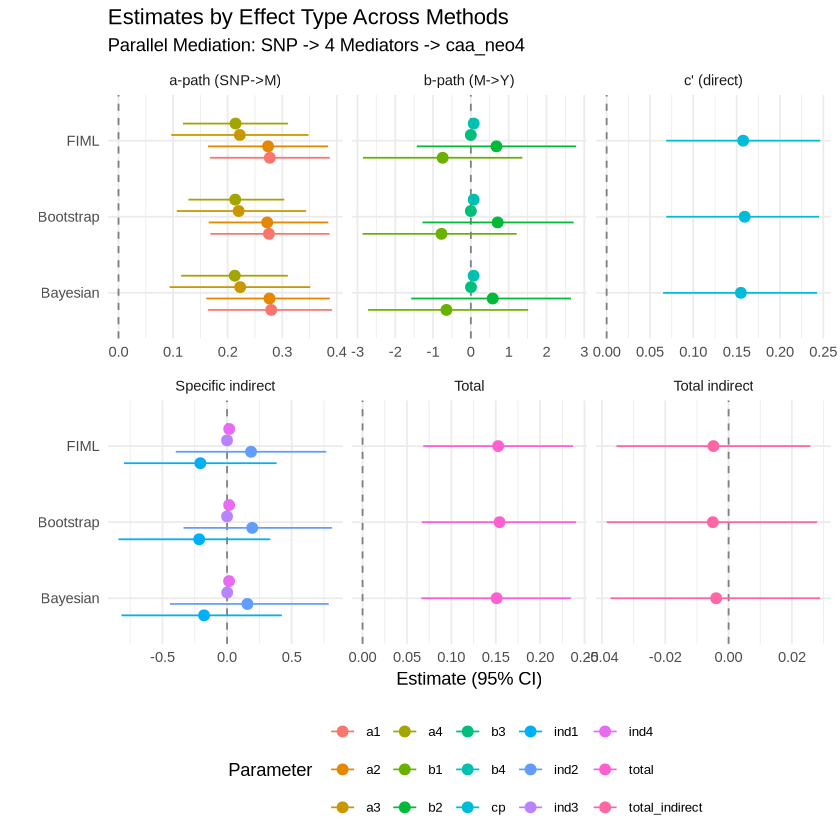

In [24]:
# ============================================================
# Section 9d: Faceted by Effect Type
# ============================================================
sum_plot2 <- all_summary[all_summary$label %in% plot_labels_summary, ]
sum_plot2$effect_type <- ifelse(grepl("^a", sum_plot2$label), "a-path (SNP->M)",
                         ifelse(grepl("^b", sum_plot2$label), "b-path (M->Y)",
                         ifelse(sum_plot2$label == "cp", "c' (direct)",
                         ifelse(grepl("^ind", sum_plot2$label), "Specific indirect",
                         ifelse(sum_plot2$label == "total_indirect", "Total indirect", "Total")))))

p_faceted <- ggplot(sum_plot2, aes(x=est, y=method, xmin=ci_lower, xmax=ci_upper, color=label)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(position=position_dodge(width=0.6), size=0.5) +
  facet_wrap(~effect_type, scales="free_x", ncol=3) +
  labs(title="Estimates by Effect Type Across Methods",
       subtitle="Parallel Mediation: SNP -> 4 Mediators -> caa_neo4",
       x="Estimate (95% CI)", y="", color="Parameter") +
  theme_minimal(base_size=11) +
  theme(legend.position="bottom", legend.text=element_text(size=8))

ggsave(file.path(RESULT_DIR, "summary", "summary_faceted_by_path.png"), p_faceted, width=14, height=8, dpi=150)
ggsave(file.path(RESULT_DIR, "summary", "summary_faceted_by_path.pdf"), p_faceted, width=14, height=8)
print(p_faceted)
cat("Faceted-by-path plot saved.\n")

Indirect effect focus plot saved.


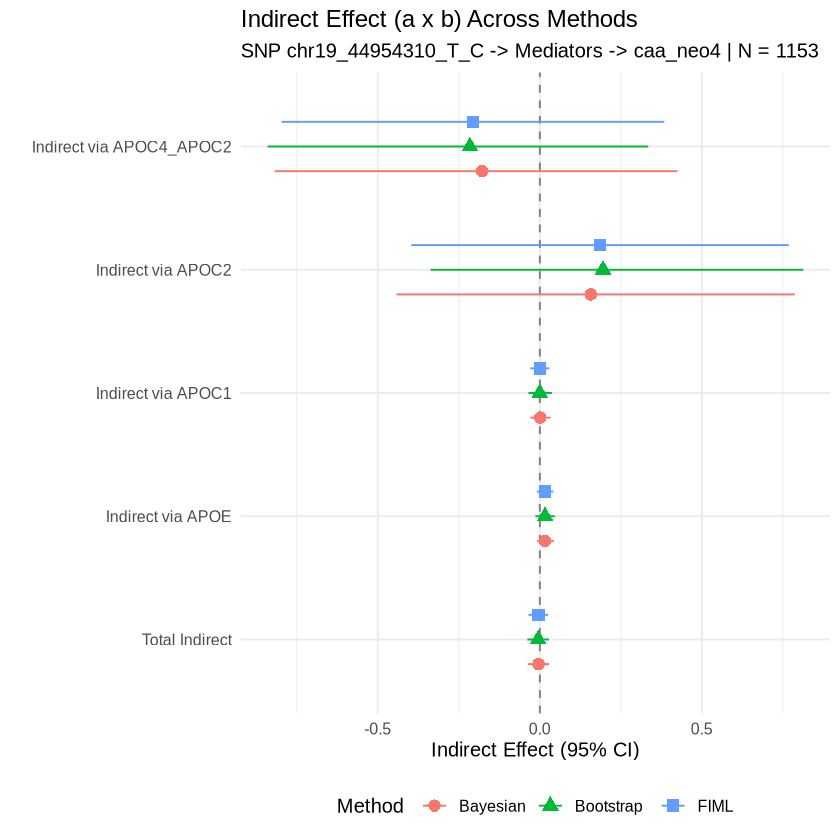

In [25]:
# ============================================================
# Section 9e: Indirect Effect Focus Plot
# ============================================================
ind_focus <- all_summary[all_summary$label %in% c(paste0("ind", 1:n_med), "total_indirect"), ]

ind_label_map <- c(
  setNames(paste0("Indirect via ", MEDIATOR_SHORT), paste0("ind", 1:n_med)),
  c(total_indirect="Total Indirect")
)
ind_focus$label_display <- ind_label_map[ind_focus$label]
ind_focus$label_display <- factor(ind_focus$label_display,
  levels=rev(c(paste0("Indirect via ", MEDIATOR_SHORT), "Total Indirect")))

p_indirect <- ggplot(ind_focus, aes(x=est, y=label_display, xmin=ci_lower, xmax=ci_upper,
                                    color=method, shape=method)) +
  geom_vline(xintercept=0, linetype="dashed", color="grey50") +
  geom_pointrange(position=position_dodge(width=0.6), size=0.7) +
  labs(title="Indirect Effect (a x b) Across Methods",
       subtitle=paste0("SNP ", EXPOSURE, " -> Mediators -> caa_neo4 | N = ", N_total),
       x="Indirect Effect (95% CI)", y="", color="Method", shape="Method") +
  theme_minimal(base_size=12) +
  theme(legend.position="bottom")

ggsave(file.path(RESULT_DIR, "summary", "summary_indirect_effect.png"), p_indirect, width=10, height=5, dpi=150)
ggsave(file.path(RESULT_DIR, "summary", "summary_indirect_effect.pdf"), p_indirect, width=10, height=5)
print(p_indirect)
cat("Indirect effect focus plot saved.\n")

Combined panel saved.


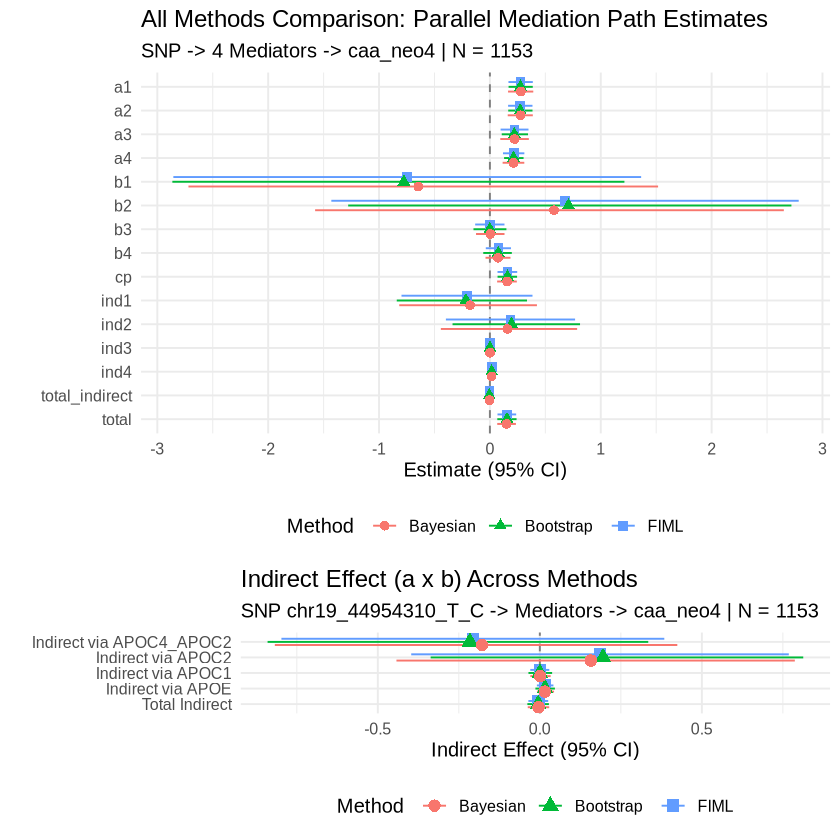

In [26]:
# ============================================================
# Section 9f: Combined Panel
# ============================================================
p_combined <- gridExtra::grid.arrange(p_sum_forest, p_indirect, nrow=2, heights=c(2, 1))

ggsave(file.path(RESULT_DIR, "summary", "summary_combined_panel.png"), p_combined, width=11, height=13, dpi=150)
ggsave(file.path(RESULT_DIR, "summary", "summary_combined_panel.pdf"), p_combined, width=11, height=13)
cat("Combined panel saved.\n")

## Key Findings

Data-driven conclusions are presented below based on the actual results from the four methods.

In [27]:
# ============================================================
# Section 10: Key Findings -- data-driven summary
# ============================================================
cat("============================================\n")
cat("KEY FINDINGS\n")
cat("============================================\n\n")

report_labels <- c(paste0("ind", 1:n_med), "total_indirect")
report_names <- c(paste0("Specific indirect via ", MEDIATOR_SHORT), "Total indirect")

for (k in seq_along(report_labels)) {
  lab <- report_labels[k]
  cat("--- ", report_names[k], " ---\n")

  # FIML
  f_row <- fiml_key[fiml_key$label == lab, ]
  if (nrow(f_row) > 0) {
    cat(sprintf("  FIML:      est=%.4f, 95%% CI=[%.4f, %.4f], p=%.4f %s\n",
                f_row$est, f_row$ci.lower, f_row$ci.upper, f_row$pvalue,
                ifelse(f_row$pvalue < 0.05, "*", "")))
  }

  # Bootstrap
  b_row <- boot_summary[boot_summary$label == lab, ]
  if (nrow(b_row) > 0) {
    cat(sprintf("  Bootstrap: est=%.4f, 95%% CI=[%.4f, %.4f], p=%.4f %s\n",
                b_row$mean, b_row$ci_lower, b_row$ci_upper, b_row$p_value,
                ifelse(b_row$p_value < 0.05, "*", "")))
  }

  # Bayesian
  if (!is.null(bayes_results)) {
    by_row <- bayes_results[bayes_results$label == lab, ]
    if (nrow(by_row) > 0) {
      cat(sprintf("  Bayesian:  est=%.4f, 95%% CrI=[%.4f, %.4f], P(direction)=%.3f\n",
                  by_row$mean, by_row$ci_lower, by_row$ci_upper, by_row$p_direction))
    }
  }
  cat("\n")
}

# Proportion mediated
cat("--- Proportion Mediated (FIML) ---\n")
for (k in 1:n_med) {
  p_row <- fiml_key[fiml_key$label == paste0("prop", k), ]
  if (nrow(p_row) > 0) {
    cat(sprintf("  %s: %.1f%%\n", MEDIATOR_SHORT[k], p_row$est * 100))
  }
}
pt_row <- fiml_key[fiml_key$label == "prop_total", ]
if (nrow(pt_row) > 0) {
  cat(sprintf("  Total mediated: %.1f%%\n", pt_row$est * 100))
}

# MNAR robustness
cat("\n--- MNAR Robustness ---\n")
for (k in 1:nrow(tipping)) {
  cat(sprintf("  %s: tipping distance = %s SD\n", tipping$label[k],
              ifelse(is.na(tipping$tipping_dist[k]), "never tips (always sig)",
                     sprintf("%.2f", tipping$tipping_dist[k]))))
}

KEY FINDINGS


---  Specific indirect via APOC4_APOC2  ---
  FIML:      est=-0.2067, 95% CI=[-0.7975, 0.3841], p=0.4929 
  Bootstrap: est=-0.2160, 95% CI=[-0.8402, 0.3346], p=0.4460 
  Bayesian:  est=-0.1782, 95% CrI=[-0.8179, 0.4243], P(direction)=0.723

---  Specific indirect via APOC2  ---
  FIML:      est=0.1857, 95% CI=[-0.3969, 0.7683], p=0.5322 
  Bootstrap: est=0.1949, 95% CI=[-0.3370, 0.8129], p=0.4920 
  Bayesian:  est=0.1575, 95% CrI=[-0.4425, 0.7869], P(direction)=0.702

---  Specific indirect via APOC1  ---
  FIML:      est=-0.0002, 95% CI=[-0.0295, 0.0292], p=0.9909 
  Bootstrap: est=0.0000, 95% CI=[-0.0351, 0.0379], p=0.9860 
  Bayesian:  est=0.0011, 95% CrI=[-0.0294, 0.0334], P(direction)=0.522

---  Specific indirect via APOE  ---
  FIML:      est=0.0164, 95% CI=[-0.0091, 0.0419], p=0.2082 
  Bootstrap: est=0.0160, 95% CI=[-0.0137, 0.0465], p=0.2160 
  Bayesian:  est=0.0156, 95% CrI=[-0.0087, 0.0439], P(direction)=0.902

---  Total indirect  ---
  FIML:      est=-0.0048, 95% CI=[-0.0

--- Proportion Mediated (FIML) ---


  APOC4_APOC2: -135.3%
  APOC2: 121.6%
  APOC1: -0.1%
  APOE: 10.7%


  Total mediated: -3.1%



--- MNAR Robustness ---


  ind1: tipping distance = 0.00 SD
  ind2: tipping distance = 0.00 SD
  ind3: tipping distance = 0.00 SD
  ind4: tipping distance = 0.00 SD
  total_indirect: tipping distance = 0.00 SD


In [28]:
# ============================================================
# Section 10b: Residual correlations between mediators (FIML)
# ============================================================
cat("\n--- Residual Correlations Between Mediators (FIML) ---\n")
pe_cov <- pe_fiml[pe_fiml$op == "~~" & pe_fiml$lhs != pe_fiml$rhs, ]
pe_cov_med <- pe_cov[pe_cov$lhs %in% MEDIATORS & pe_cov$rhs %in% MEDIATORS, ]
if (nrow(pe_cov_med) > 0) {
  for (i in 1:nrow(pe_cov_med)) {
    cat(sprintf("  %s ~~ %s: est=%.4f, SE=%.4f, p=%.4f\n",
                pe_cov_med$lhs[i], pe_cov_med$rhs[i],
                pe_cov_med$est[i], pe_cov_med$se[i], pe_cov_med$pvalue[i]))
  }
} else {
  cat("  No mediator-mediator covariances found (may be default-estimated).\n")
}


--- Residual Correlations Between Mediators (FIML) ---


  APOC4_APOC2_AC_exp ~~ APOC2_AC_exp: est=0.8890, SE=0.0517, p=0.0000
  APOC4_APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp: est=0.2048, SE=0.0537, p=0.0001
  APOC4_APOC2_AC_exp ~~ APOE_Mega_Mic_exp: est=0.0527, SE=0.0416, p=0.2046
  APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp: est=0.2079, SE=0.0539, p=0.0001
  APOC2_AC_exp ~~ APOE_Mega_Mic_exp: est=0.0539, SE=0.0417, p=0.1957
  APOC1_DeJager_Mic_exp ~~ APOE_Mega_Mic_exp: est=0.5709, SE=0.0501, p=0.0000


## Output File Inventory

In [29]:
# ============================================================
# Section 11: Output File Inventory
# ============================================================
cat("\n=== Output File Inventory ===\n")
all_files <- list.files(RESULT_DIR, recursive=TRUE, full.names=FALSE)
all_files <- all_files[!grepl("^log/", all_files)]
for (f in sort(all_files)) {
  cat(" ", f, "\n")
}


=== Output File Inventory ===


  APOE_ind_set_27_caa_neo4_APOE4_adj_SEM_mediation.ipynb 
  bayesian_blavaan/bayesian_forest_plot.pdf 
  bayesian_blavaan/bayesian_forest_plot.png 
  bayesian_blavaan/bayesian_posteriors_chr19_44954310_T_C.pdf 
  bayesian_blavaan/bayesian_posteriors_chr19_44954310_T_C.png 
  bayesian_blavaan/bayesian_results.csv 
  bayesian_blavaan/bayesian_trace_a_chr19_44954310_T_C.pdf 
  bayesian_blavaan/bayesian_trace_a_chr19_44954310_T_C.png 
  bootstrap/bootstrap_distributions_chr19_44954310_T_C.pdf 
  bootstrap/bootstrap_distributions_chr19_44954310_T_C.png 
  bootstrap/bootstrap_forest_plot.pdf 
  bootstrap/bootstrap_forest_plot.png 
  bootstrap/bootstrap_results.csv 
  gen_notebook.py 
  main_SEM_FIML/fiml_all_paths.csv 
  main_SEM_FIML/fiml_forest_plot.pdf 
  main_SEM_FIML/fiml_forest_plot.png 
  MNAR_sensitivity/mnar_1d_slices_chr19_44954310_T_C.pdf 
  MNAR_sensitivity/mnar_1d_slices_chr19_44954310_T_C.png 
  MNAR_sensitivity/mnar_contour_indirect_chr19_44954310_T_C.pdf 
  MNAR_sensitivity/m

## Sensitivity Analysis: Parallel Mediation Excluding APOC4_APOC2_AC_exp

This sensitivity analysis repeats the FIML parallel mediation with only 3 mediators,
**excluding APOC4_APOC2_AC_exp**. The purpose is to assess whether the mediation results
are driven by the APOC4_APOC2 mediator (which showed high collinearity with APOC2_AC_exp)
or whether the remaining 3 mediators carry independent mediation signal.

### Mediators retained:
1. **APOC2_AC_exp** (covariates: msex_u, age_death_u, pmi_u, ROS_study_u)
2. **APOC1_DeJager_Mic_exp** (covariates: msex_u, age_death_u, pmi_u)
3. **APOE_Mega_Mic_exp** (covariates: msex_u, age_death_u, pmi_u)

### Outcome:
- **caa_neo4** (covariates: educ, apoe4_dose, msex_u, age_death_u)


In [4]:
# ============================================================
# Sensitivity Analysis: FIML SEM with 3 Mediators (excluding APOC4_APOC2_AC_exp)
# ============================================================
cat("=== Sensitivity Analysis: 3-Mediator Model (excl. APOC4_APOC2_AC_exp) ===\n\n")

# Create output directory
SENS_DIR <- file.path(RESULT_DIR, "main_SEM_FIML", "sensitivity_analysis")
dir.create(SENS_DIR, showWarnings=FALSE, recursive=TRUE)

# Define 3-mediator variables
SENS_MEDIATORS <- c("APOC2_AC_exp", "APOC1_DeJager_Mic_exp", "APOE_Mega_Mic_exp")
SENS_MEDIATOR_SHORT <- c("APOC2", "APOC1", "APOE")
n_med_sens <- length(SENS_MEDIATORS)

# Covariates per mediator equation
SENS_MED_COVS <- list(
  APOC2_AC_exp = c("msex_u", "age_death_u", "pmi_u", "ROS_study_u"),
  APOC1_DeJager_Mic_exp = c("msex_u", "age_death_u", "pmi_u"),
  APOE_Mega_Mic_exp = c("msex_u", "age_death_u", "pmi_u")
)

# Build mediator equations
sens_med_eqs <- c()
for (i in seq_len(n_med_sens)) {
  m <- SENS_MEDIATORS[i]
  cov_str <- paste(SENS_MED_COVS[[m]], collapse=" + ")
  sens_med_eqs <- c(sens_med_eqs, paste0(m, " ~ a", i, " * ", EXPOSURE, " + ", cov_str))
}

# Outcome equation
sens_med_terms <- paste0("b", seq_len(n_med_sens), " * ", SENS_MEDIATORS, collapse=" + ")
sens_y_eq <- paste0(OUTCOME, " ~ ", sens_med_terms, " + cp * ", EXPOSURE, " + ", paste(OUT_COVS, collapse=" + "))

# Defined parameters
sens_ind_defs <- paste0("ind", seq_len(n_med_sens), " := a", seq_len(n_med_sens), " * b", seq_len(n_med_sens))
sens_total_ind <- paste0("total_indirect := ", paste0("ind", seq_len(n_med_sens), collapse=" + "))
sens_total_def <- "total := cp + total_indirect"
sens_prop_defs <- paste0("prop", seq_len(n_med_sens), " := ind", seq_len(n_med_sens), " / total")
sens_prop_total <- "prop_total := total_indirect / total"

# Pairwise contrasts
sens_contrasts <- c()
for (i in 1:(n_med_sens-1)) {
  for (j in (i+1):n_med_sens) {
    sens_contrasts <- c(sens_contrasts, paste0("diff_", i, "_", j, " := ind", i, " - ind", j))
  }
}

# Residual correlations between mediators
sens_cov_terms <- c()
for (i in 1:(n_med_sens-1)) {
  for (j in (i+1):n_med_sens) {
    sens_cov_terms <- c(sens_cov_terms, paste0(SENS_MEDIATORS[i], " ~~ ", SENS_MEDIATORS[j]))
  }
}

sens_model_str <- paste(c(sens_med_eqs, sens_y_eq, sens_ind_defs, sens_total_ind, sens_total_def,
                           sens_prop_defs, sens_prop_total, sens_contrasts, sens_cov_terms), collapse="\n")

cat("=== 3-Mediator Parallel Model ===\n")
cat(sens_model_str, "\n\n")

# Fit FIML
cat("Fitting FIML SEM (N =", N_total, ")...\n")
fit_sens <- tryCatch(
  sem(sens_model_str, data=dat, missing="fiml", fixed.x=FALSE, estimator="ML"),
  error = function(e) { cat("FIML Error:", conditionMessage(e), "\n"); NULL }
)

if (!is.null(fit_sens)) {
  cat("Converged:", lavInspect(fit_sens, "converged"), "\n")
  cat("N used:", lavInspect(fit_sens, "nobs"), "\n\n")
  summary(fit_sens, fit.measures=TRUE, standardized=TRUE)
} else {
  cat("ERROR: Model failed to converge.\n")
}


=== Sensitivity Analysis: 3-Mediator Model (excl. APOC4_APOC2_AC_exp) ===



=== 3-Mediator Parallel Model ===


APOC2_AC_exp ~ a1 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u + ROS_study_u
APOC1_DeJager_Mic_exp ~ a2 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
APOE_Mega_Mic_exp ~ a3 * chr19_44954310_T_C + msex_u + age_death_u + pmi_u
caa_neo4 ~ b1 * APOC2_AC_exp + b2 * APOC1_DeJager_Mic_exp + b3 * APOE_Mega_Mic_exp + cp * chr19_44954310_T_C + educ + apoe4_dose + msex_u + age_death_u
ind1 := a1 * b1
ind2 := a2 * b2
ind3 := a3 * b3
total_indirect := ind1 + ind2 + ind3
total := cp + total_indirect
prop1 := ind1 / total
prop2 := ind2 / total
prop3 := ind3 / total
prop_total := total_indirect / total
diff_1_2 := ind1 - ind2
diff_1_3 := ind1 - ind3
diff_2_3 := ind2 - ind3
APOC2_AC_exp ~~ APOC1_DeJager_Mic_exp
APOC2_AC_exp ~~ APOE_Mega_Mic_exp
APOC1_DeJager_Mic_exp ~~ APOE_Mega_Mic_exp 



Fitting FIML SEM (N = 1153 )...


Converged: TRUE 
N used: 1153 



lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
APOC2_AC_exp,~,chr19_44954310_T_C,a1,0,0.273953641,0.056139981,4.87983137,1.061766e-06,0.273953641,0.195764781
APOC2_AC_exp,~,msex_u,,0,0.096411662,0.081675246,1.18042696,2.378304e-01,0.096411662,0.046567142
APOC2_AC_exp,~,age_death_u,,0,0.022248397,0.006037667,3.68493256,2.287632e-04,0.022248397,0.148791289
APOC2_AC_exp,~,pmi_u,,0,0.012089715,0.007920926,1.52630068,1.269350e-01,0.012089715,0.091035199
APOC2_AC_exp,~,ROS_study_u,,0,-0.160271206,0.077289404,-2.07365043,3.811179e-02,-0.160271206,-0.081585181
APOC1_DeJager_Mic_exp,~,chr19_44954310_T_C,a2,0,0.222252118,0.064197073,3.46202887,5.361197e-04,0.222252118,0.153117626
APOC1_DeJager_Mic_exp,~,msex_u,,0,-0.162289442,0.097013047,-1.67286202,9.435446e-02,-0.162289442,-0.075572201
APOC1_DeJager_Mic_exp,~,age_death_u,,0,0.008908582,0.006697564,1.33012275,1.834778e-01,0.008908582,0.057439305
APOC1_DeJager_Mic_exp,~,pmi_u,,0,0.002979722,0.008675720,0.34345532,7.312559e-01,0.002979722,0.021631710


In [5]:
# ============================================================
# Sensitivity Analysis: Extract results and save
# ============================================================
if (!is.null(fit_sens) && lavInspect(fit_sens, "converged")) {
  pe_sens <- parameterEstimates(fit_sens, ci=TRUE)
  N_sens <- lavInspect(fit_sens, "nobs")

  # Contrast labels
  sens_contrast_labels <- c()
  for (i in 1:(n_med_sens-1)) {
    for (j in (i+1):n_med_sens) {
      sens_contrast_labels <- c(sens_contrast_labels, paste0("diff_", i, "_", j))
    }
  }

  sens_all_labels <- c(paste0("a", 1:n_med_sens), paste0("b", 1:n_med_sens), "cp",
                        paste0("ind", 1:n_med_sens), "total_indirect", "total",
                        paste0("prop", 1:n_med_sens), "prop_total", sens_contrast_labels)

  sens_key <- pe_sens[pe_sens$label %in% sens_all_labels, ]
  sens_key$method <- "FIML_sensitivity_3med"
  sens_key$N <- N_sens
  sens_key$exposure <- EXPOSURE
  sens_key$direction <- "D1"

  # Readable labels
  sens_label_desc <- c(
    setNames(paste0("a", 1:n_med_sens, " (SNP->", SENS_MEDIATOR_SHORT, ")"), paste0("a", 1:n_med_sens)),
    setNames(paste0("b", 1:n_med_sens, " (", SENS_MEDIATOR_SHORT, "->caa_neo4)"), paste0("b", 1:n_med_sens)),
    c(cp="cp (SNP->caa_neo4 direct)"),
    setNames(paste0("ind", 1:n_med_sens, " (via ", SENS_MEDIATOR_SHORT, ")"), paste0("ind", 1:n_med_sens)),
    c(total_indirect="total_indirect", total="total"),
    setNames(paste0("prop", 1:n_med_sens, " (via ", SENS_MEDIATOR_SHORT, ")"), paste0("prop", 1:n_med_sens)),
    c(prop_total="prop_total"),
    setNames(sens_contrast_labels, sens_contrast_labels)
  )
  sens_key$label_desc <- sens_label_desc[sens_key$label]
  sens_key$label_desc[is.na(sens_key$label_desc)] <- sens_key$label[is.na(sens_key$label_desc)]

  # Save CSV
  write.csv(sens_key, file.path(SENS_DIR, "fiml_sensitivity_3med_all_paths.csv"), row.names=FALSE)

  # Print key results
  cat("\n=== Sensitivity Analysis: FIML Key Results (N =", N_sens, ", 3 mediators) ===\n")
  print(sens_key[, c("label", "label_desc", "est", "se", "ci.lower", "ci.upper", "pvalue", "N")])

  # ----- Fit measures -----
  fm_sens <- fitMeasures(fit_sens, c("chisq", "df", "pvalue", "cfi", "tli", "rmsea", "srmr", "aic", "bic"))
  fm_df <- data.frame(measure=names(fm_sens), value=as.numeric(fm_sens), model="3-mediator sensitivity")
  write.csv(fm_df, file.path(SENS_DIR, "fiml_sensitivity_3med_fit_measures.csv"), row.names=FALSE)
  cat("\n=== Fit Measures (3-mediator sensitivity) ===\n")
  print(fm_df)

  # ----- Residual correlations between mediators -----
  cat("\n=== Residual Correlations Between Mediators ===\n")
  res_cov <- pe_sens[pe_sens$op == "~~" & pe_sens$lhs %in% SENS_MEDIATORS & pe_sens$rhs %in% SENS_MEDIATORS & pe_sens$lhs != pe_sens$rhs, ]
  if (nrow(res_cov) > 0) {
    print(res_cov[, c("lhs", "rhs", "est", "se", "ci.lower", "ci.upper", "pvalue")])
  }
} else {
  cat("Skipping result extraction -- model did not converge.\n")
}



=== Sensitivity Analysis: FIML Key Results (N = 1153 , 3 mediators) ===
            label                label_desc    est    se ci.lower ci.upper
1              a1           a1 (SNP->APOC2)  0.274 0.056    0.164    0.384
6              a2           a2 (SNP->APOC1)  0.222 0.064    0.096    0.348
10             a3            a3 (SNP->APOE)  0.214 0.049    0.118    0.311
14             b1      b1 (APOC2->caa_neo4) -0.067 0.044   -0.154    0.020
15             b2      b2 (APOC1->caa_neo4)  0.005 0.067   -0.127    0.137
16             b3       b3 (APOE->caa_neo4)  0.075 0.058   -0.039    0.188
17             cp cp (SNP->caa_neo4 direct)  0.153 0.045    0.065    0.242
68           ind1          ind1 (via APOC2) -0.018 0.013   -0.043    0.006
69           ind2          ind2 (via APOC1)  0.001 0.015   -0.028    0.031
70           ind3           ind3 (via APOE)  0.016 0.013   -0.009    0.041
71 total_indirect            total_indirect -0.001 0.015   -0.030    0.028
72          total          

=== Comparison: 4-Mediator vs 3-Mediator Model ===

Comparison table (4-mediator vs 3-mediator):
   mediator                 path      est_4med    se_4med       p_4med
1     APOC2       a (SNP->APOC2)  0.2740327333 0.05613088 1.049985e-06
2     APOC1       a (SNP->APOC1)  0.2223019945 0.06417651 5.323741e-04
3      APOE        a (SNP->APOE)  0.2144028883 0.04914068 1.282657e-05
4     APOC2  b (APOC2->caa_neo4)  0.6776563284 1.07551466 5.286446e-01
5     APOC1  b (APOC1->caa_neo4) -0.0007661479 0.06743492 9.909352e-01
6      APOE   b (APOE->caa_neo4)  0.0764241644 0.05793341 1.871114e-01
7     APOC2 indirect (via APOC2)  0.1857000159 0.29727556 5.321857e-01
8     APOC1 indirect (via APOC1) -0.0001703162 0.01498653 9.909325e-01
9      APOE  indirect (via APOE)  0.0163855616 0.01301868 2.081679e-01
10   global                   cp  0.1575068431 0.04533119 5.116535e-04
11   global       total_indirect -0.0047847136 0.01561455 7.592798e-01
12   global                total  0.1527221295 0.04


Forest plot saved.



Comparison forest plot saved.


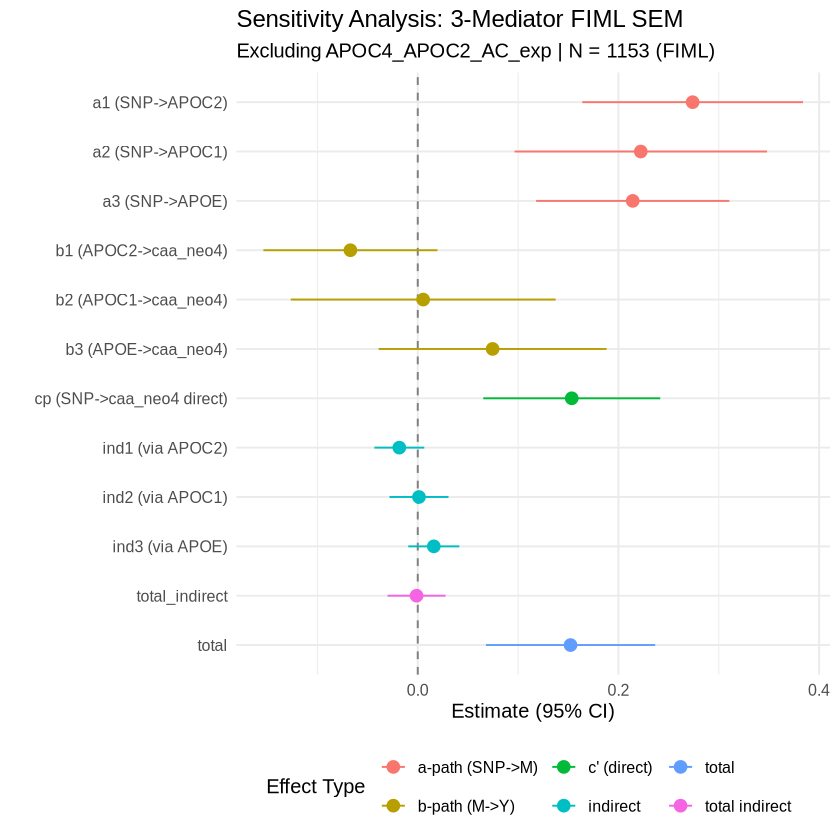

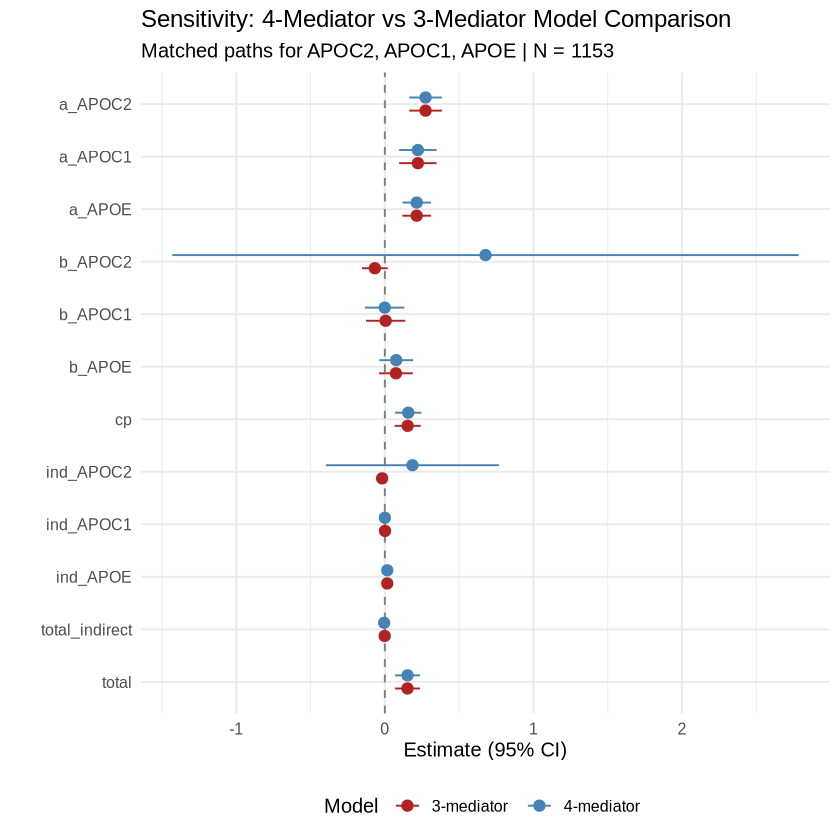

In [6]:
# ============================================================
# Sensitivity Analysis: Comparison with 4-mediator model + Forest Plot
# ============================================================
if (!is.null(fit_sens) && lavInspect(fit_sens, "converged")) {

  # --- Comparison table ---
  # Map 3-med labels to comparable 4-med labels
  # In 4-med model: a1=APOC4_APOC2, a2=APOC2, a3=APOC1, a4=APOE
  # In 3-med model: a1=APOC2, a2=APOC1, a3=APOE
  # We compare matching mediators
  cat("=== Comparison: 4-Mediator vs 3-Mediator Model ===\n\n")

  fiml_4med <- read.csv(file.path(RESULT_DIR, "main_SEM_FIML", "fiml_all_paths.csv"), stringsAsFactors=FALSE)

  # Build comparison for matching paths
  comparison_rows <- list()

  # a-paths: map 3-med indices to 4-med mediator names
  med_map <- data.frame(
    mediator = SENS_MEDIATOR_SHORT,
    label_3med = paste0("a", 1:n_med_sens),
    label_4med = c("a2", "a3", "a4"),  # APOC2=a2, APOC1=a3, APOE=a4 in 4-med
    stringsAsFactors = FALSE
  )

  for (r in seq_len(nrow(med_map))) {
    row_3 <- sens_key[sens_key$label == med_map$label_3med[r], ]
    row_4 <- fiml_4med[fiml_4med$label == med_map$label_4med[r], ]
    if (nrow(row_3) == 1 && nrow(row_4) == 1) {
      comparison_rows[[length(comparison_rows)+1]] <- data.frame(
        mediator = med_map$mediator[r],
        path = paste0("a (SNP->", med_map$mediator[r], ")"),
        est_4med = row_4$est, se_4med = row_4$se, p_4med = row_4$pvalue,
        est_3med = row_3$est, se_3med = row_3$se, p_3med = row_3$pvalue,
        stringsAsFactors = FALSE
      )
    }
  }

  # b-paths
  b_map <- data.frame(
    mediator = SENS_MEDIATOR_SHORT,
    label_3med = paste0("b", 1:n_med_sens),
    label_4med = c("b2", "b3", "b4"),
    stringsAsFactors = FALSE
  )
  for (r in seq_len(nrow(b_map))) {
    row_3 <- sens_key[sens_key$label == b_map$label_3med[r], ]
    row_4 <- fiml_4med[fiml_4med$label == b_map$label_4med[r], ]
    if (nrow(row_3) == 1 && nrow(row_4) == 1) {
      comparison_rows[[length(comparison_rows)+1]] <- data.frame(
        mediator = b_map$mediator[r],
        path = paste0("b (", b_map$mediator[r], "->caa_neo4)"),
        est_4med = row_4$est, se_4med = row_4$se, p_4med = row_4$pvalue,
        est_3med = row_3$est, se_3med = row_3$se, p_3med = row_3$pvalue,
        stringsAsFactors = FALSE
      )
    }
  }

  # Specific indirect effects
  ind_map <- data.frame(
    mediator = SENS_MEDIATOR_SHORT,
    label_3med = paste0("ind", 1:n_med_sens),
    label_4med = c("ind2", "ind3", "ind4"),
    stringsAsFactors = FALSE
  )
  for (r in seq_len(nrow(ind_map))) {
    row_3 <- sens_key[sens_key$label == ind_map$label_3med[r], ]
    row_4 <- fiml_4med[fiml_4med$label == ind_map$label_4med[r], ]
    if (nrow(row_3) == 1 && nrow(row_4) == 1) {
      comparison_rows[[length(comparison_rows)+1]] <- data.frame(
        mediator = ind_map$mediator[r],
        path = paste0("indirect (via ", ind_map$mediator[r], ")"),
        est_4med = row_4$est, se_4med = row_4$se, p_4med = row_4$pvalue,
        est_3med = row_3$est, se_3med = row_3$se, p_3med = row_3$pvalue,
        stringsAsFactors = FALSE
      )
    }
  }

  # cp, total_indirect, total
  for (lab in c("cp", "total_indirect", "total")) {
    row_3 <- sens_key[sens_key$label == lab, ]
    row_4 <- fiml_4med[fiml_4med$label == lab, ]
    if (nrow(row_3) == 1 && nrow(row_4) == 1) {
      comparison_rows[[length(comparison_rows)+1]] <- data.frame(
        mediator = "global",
        path = lab,
        est_4med = row_4$est, se_4med = row_4$se, p_4med = row_4$pvalue,
        est_3med = row_3$est, se_3med = row_3$se, p_3med = row_3$pvalue,
        stringsAsFactors = FALSE
      )
    }
  }

  comp_df <- do.call(rbind, comparison_rows)
  comp_df$delta_est <- comp_df$est_3med - comp_df$est_4med
  write.csv(comp_df, file.path(SENS_DIR, "fiml_sensitivity_comparison_4v3med.csv"), row.names=FALSE)

  cat("Comparison table (4-mediator vs 3-mediator):\n")
  print(comp_df)

  # --- Forest Plot ---
  # Plot the 3-mediator results (a, b, cp, indirect, total)
  plot_labels <- c(paste0("a", 1:n_med_sens), paste0("b", 1:n_med_sens), "cp",
                    paste0("ind", 1:n_med_sens), "total_indirect", "total")
  plot_df <- sens_key[sens_key$label %in% plot_labels, ]
  # Exclude proportion rows from forest
  plot_df <- plot_df[!grepl("^prop", plot_df$label), ]

  # Assign effect type for color grouping
  plot_df$effect_type <- ifelse(grepl("^a", plot_df$label), "a-path (SNP->M)",
                          ifelse(grepl("^b", plot_df$label), "b-path (M->Y)",
                          ifelse(plot_df$label == "cp", "c' (direct)",
                          ifelse(grepl("^ind", plot_df$label), "indirect",
                          ifelse(plot_df$label == "total_indirect", "total indirect",
                          "total")))))

  # Order
  plot_df$label_desc <- factor(plot_df$label_desc, levels=rev(plot_df$label_desc))

  p_sens <- ggplot(plot_df, aes(x=est, y=label_desc, xmin=ci.lower, xmax=ci.upper, color=effect_type)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(size=0.6) +
    labs(title="Sensitivity Analysis: 3-Mediator FIML SEM",
         subtitle=paste0("Excluding APOC4_APOC2_AC_exp | N = ", N_sens, " (FIML)"),
         x="Estimate (95% CI)", y="", color="Effect Type") +
    theme_minimal(base_size=12) +
    theme(legend.position="bottom")

  ggsave(file.path(SENS_DIR, "fiml_sensitivity_3med_forest_plot.png"), p_sens, width=10, height=7, dpi=150)
  ggsave(file.path(SENS_DIR, "fiml_sensitivity_3med_forest_plot.pdf"), p_sens, width=10, height=7)
  cat("\nForest plot saved.\n")
  print(p_sens)

  # --- Side-by-side forest: 4-med vs 3-med for matched paths ---
  # Build a combined df for the overlay
  matched_3 <- sens_key[sens_key$label %in% plot_labels, c("label", "est", "ci.lower", "ci.upper")]
  matched_3$model <- "3-mediator"
  # Remap labels to mediator names for matching
  matched_3$mediator_label <- matched_3$label
  matched_3$mediator_label <- gsub("a1", "a_APOC2", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("a2", "a_APOC1", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("a3", "a_APOE", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("b1", "b_APOC2", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("b2", "b_APOC1", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("b3", "b_APOE", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("ind1", "ind_APOC2", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("ind2", "ind_APOC1", matched_3$mediator_label)
  matched_3$mediator_label <- gsub("ind3", "ind_APOE", matched_3$mediator_label)

  # 4-mediator matched paths (excluding APOC4_APOC2 specific paths)
  matched_4_labels <- c("a2", "a3", "a4", "b2", "b3", "b4", "cp", "ind2", "ind3", "ind4", "total_indirect", "total")
  matched_4 <- fiml_4med[fiml_4med$label %in% matched_4_labels, c("label", "est", "ci.lower", "ci.upper")]
  matched_4$model <- "4-mediator"
  matched_4$mediator_label <- matched_4$label
  matched_4$mediator_label <- gsub("a2", "a_APOC2", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("a3", "a_APOC1", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("a4", "a_APOE", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("b2", "b_APOC2", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("b3", "b_APOC1", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("b4", "b_APOE", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("ind2", "ind_APOC2", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("ind3", "ind_APOC1", matched_4$mediator_label)
  matched_4$mediator_label <- gsub("ind4", "ind_APOE", matched_4$mediator_label)

  overlay_df <- rbind(matched_3[, c("mediator_label", "est", "ci.lower", "ci.upper", "model")],
                       matched_4[, c("mediator_label", "est", "ci.lower", "ci.upper", "model")])
  overlay_df$mediator_label <- factor(overlay_df$mediator_label,
    levels=rev(c("a_APOC2", "a_APOC1", "a_APOE", "b_APOC2", "b_APOC1", "b_APOE",
                 "cp", "ind_APOC2", "ind_APOC1", "ind_APOE", "total_indirect", "total")))

  p_compare <- ggplot(overlay_df, aes(x=est, y=mediator_label, xmin=ci.lower, xmax=ci.upper, color=model)) +
    geom_vline(xintercept=0, linetype="dashed", color="grey50") +
    geom_pointrange(position=position_dodge(width=0.5), size=0.5) +
    scale_color_manual(values=c("4-mediator"="steelblue", "3-mediator"="firebrick")) +
    labs(title="Sensitivity: 4-Mediator vs 3-Mediator Model Comparison",
         subtitle=paste0("Matched paths for APOC2, APOC1, APOE | N = ", N_sens),
         x="Estimate (95% CI)", y="", color="Model") +
    theme_minimal(base_size=12) +
    theme(legend.position="bottom")

  ggsave(file.path(SENS_DIR, "fiml_sensitivity_4v3_comparison_forest.png"), p_compare, width=10, height=7, dpi=150)
  ggsave(file.path(SENS_DIR, "fiml_sensitivity_4v3_comparison_forest.pdf"), p_compare, width=10, height=7)
  cat("\nComparison forest plot saved.\n")
  print(p_compare)
} else {
  cat("Skipping plots -- model did not converge.\n")
}


### Sensitivity Analysis Interpretation

This sensitivity analysis compares the 4-mediator parallel model (original) with a reduced 3-mediator
model that excludes APOC4_APOC2_AC_exp. Key points to assess:

1. **a-paths (SNP->M):** These should be virtually identical between models since mediator equations
   are independent of each other (each mediator regressed on SNP + its own covariates).
2. **b-paths (M->Y):** These may change because removing a correlated mediator alters the conditional
   associations. If APOC4_APOC2 and APOC2 were highly correlated, the b-path for APOC2 may become
   more stable (less multicollinearity).
3. **Indirect effects:** Changes here reflect both any b-path changes and the removal of the
   APOC4_APOC2-specific indirect pathway.
4. **Direct effect (cp):** If APOC4_APOC2 was absorbing some of the direct effect, cp may change.
5. **Total effect:** Should remain similar (the total causal effect of SNP on outcome is model-invariant
   if the model is correctly specified).


In [7]:
# ============================================================
# Section 12: Save session_notes.md
# ============================================================
notes <- paste0(
  "# Session Notes: SEM Parallel Mediation Analysis\n",
  "\n",
  "## Analysis Summary\n",
  "- **Design:** Parallel mediation (Design 2) with 4 mediators\n",
  "- **Direction:** Unidirectional (SNP -> M -> Y)\n",
  "- **Exposure:** chr19_44954310_T_C\n",
  "- **Mediators:** APOC4_APOC2_AC_exp, APOC2_AC_exp, APOC1_DeJager_Mic_exp, APOE_Mega_Mic_exp\n",
  "- **Outcome:** caa_neo4\n",
  "- **Sample size:** N = ", N_total, " (FIML, all subjects with exposure observed)\n",
  "- **Covariate strategy:** Covariates-in-model (Strategy A)\n",
  "\n",
  "## Methods\n",
  "1. FIML SEM (lavaan) -- primary analysis\n",
  "2. Bootstrap (1000 replicates, FIML inside) -- non-parametric CIs\n",
  "3. MNAR Sensitivity (15x15 delta grid) -- robustness to missing data assumptions\n",
  "4. Bayesian SEM (blavaan/Stan) -- posterior inference\n",
  "\n",
  "## Key Findings\n",
  "See all_methods_summary.csv and summary plots for detailed results.\n",
  "\n",
  "## Notes\n",
  "- All four mediators tested simultaneously in one model (parallel/joint mediation)\n",
  "- Specific indirect effects represent the UNIQUE contribution of each mediator\n",
  "- Residual correlations between mediators freely estimated\n",
  "- Substantial missingness in mediators (37-64%) handled by FIML\n",
  "\n",
  "## Sensitivity Analysis (added)\n",
  "- 3-mediator model excluding APOC4_APOC2_AC_exp\n",
  "- Compared matched paths between 4-med and 3-med models\n",
  "- Results in main_SEM_FIML/sensitivity_analysis/\n",
  "\n",
  "## Recommended Follow-up\n",
  "- Compare with separate (marginal) mediation for each mediator to see if results differ\n",
  "- Test interaction terms (SNP x mediator) if suppression effects detected\n",
  "- Sensitivity analysis with different APOE adjustment strategies\n"
)

writeLines(notes, file.path(RESULT_DIR, "session_notes.md"))
cat("session_notes.md saved.\n")

session_notes.md saved.


## Post-Analysis Sanity Check

In [31]:
# ============================================================
# Section 13: Sanity Check
# ============================================================
cat("============================================\n")
cat("POST-ANALYSIS SANITY CHECK\n")
cat("============================================\n\n")

passed <- c()
warnings_list <- c()
anomalies <- c()

# 1. Sign consistency across methods
cat("--- Check 1: Sign Consistency ---\n")
check_labels <- c(paste0("a", 1:n_med), paste0("b", 1:n_med), "cp",
                  paste0("ind", 1:n_med), "total_indirect")
sign_issues <- c()
for (lab in check_labels) {
  ests <- all_summary$est[all_summary$label == lab]
  if (length(ests) >= 2 && !all(is.na(ests))) {
    signs <- sign(ests[!is.na(ests)])
    if (length(unique(signs[signs != 0])) > 1) {
      sign_issues <- c(sign_issues, lab)
    }
  }
}
if (length(sign_issues) == 0) {
  passed <- c(passed, "Sign consistency: All methods agree on direction for all paths")
  cat("  PASSED\n")
} else {
  msg <- paste0("Sign disagreement for: ", paste(sign_issues, collapse=", "))
  anomalies <- c(anomalies, msg)
  cat("  ANOMALY:", msg, "\n")
}

# 2. Magnitude discrepancies
cat("\n--- Check 2: Magnitude Discrepancies ---\n")
mag_issues <- c()
for (lab in check_labels) {
  ests <- abs(all_summary$est[all_summary$label == lab])
  ests <- ests[!is.na(ests) & ests > 0]
  if (length(ests) >= 2) {
    if (max(ests) / min(ests) > 3) {
      mag_issues <- c(mag_issues, sprintf("%s (ratio=%.1f)", lab, max(ests)/min(ests)))
    }
  }
}
if (length(mag_issues) == 0) {
  passed <- c(passed, "Magnitude consistency: No method differs by >3x from others")
  cat("  PASSED\n")
} else {
  msg <- paste0("Magnitude discrepancy: ", paste(mag_issues, collapse="; "))
  warnings_list <- c(warnings_list, msg)
  cat("  WARNING:", msg, "\n")
}

# 3. Significance disagreements for indirect effects
cat("\n--- Check 3: Significance Disagreements ---\n")
sig_disagree_found <- FALSE
for (lab in c(paste0("ind", 1:n_med), "total_indirect")) {
  sub <- all_summary[all_summary$label == lab, ]
  sig_fiml <- any(sub$pvalue[sub$method == "FIML"] < 0.05, na.rm=TRUE)
  boot_row <- sub[sub$method == "Bootstrap", ]
  sig_boot <- nrow(boot_row) > 0 && !is.na(boot_row$ci_lower) && !is.na(boot_row$ci_upper) && (boot_row$ci_lower * boot_row$ci_upper > 0)
  bayes_row <- sub[sub$method == "Bayesian", ]
  sig_bayes <- nrow(bayes_row) > 0 && !is.na(bayes_row$ci_lower) && !is.na(bayes_row$ci_upper) && (bayes_row$ci_lower * bayes_row$ci_upper > 0)

  sigs <- c(FIML=sig_fiml, Bootstrap=sig_boot, Bayesian=sig_bayes)
  sigs <- sigs[!is.na(sigs)]

  if (length(unique(sigs)) > 1) {
    msg <- sprintf("%s: %s", lab, paste(names(sigs), ifelse(sigs, "sig", "NS"), sep="=", collapse=", "))
    warnings_list <- c(warnings_list, msg)
    cat("  WARNING:", msg, "\n")
    sig_disagree_found <- TRUE
  }
}
if (!sig_disagree_found) {
  passed <- c(passed, "Significance agreement: All methods agree on indirect effect significance")
  cat("  PASSED\n")
}

# 4. Proportion mediated out of range
cat("\n--- Check 4: Proportion Mediated Range ---\n")
prop_ok <- TRUE
for (k in 1:n_med) {
  p_row <- fiml_key[fiml_key$label == paste0("prop", k), ]
  if (nrow(p_row) > 0 && !is.na(p_row$est)) {
    if (p_row$est < 0 || p_row$est > 1) {
      msg <- sprintf("prop%d (%s) = %.2f -- %s", k, MEDIATOR_SHORT[k], p_row$est,
                     ifelse(p_row$est < 0, "suppression effect", "direct/indirect opposite signs"))
      warnings_list <- c(warnings_list, msg)
      cat("  WARNING:", msg, "\n")
      prop_ok <- FALSE
    }
  }
}
if (prop_ok) {
  passed <- c(passed, "Proportion mediated: All within [0, 1] range")
  cat("  PASSED\n")
}

# 5. Large SEs
cat("\n--- Check 5: Large Standard Errors ---\n")
se_issues <- c()
for (lab in c(paste0("ind", 1:n_med), "total_indirect")) {
  sub <- all_summary[all_summary$label == lab, ]
  for (i in 1:nrow(sub)) {
    if (!is.na(sub$se[i]) && !is.na(sub$est[i]) && abs(sub$est[i]) > 0) {
      if (sub$se[i] > 5 * abs(sub$est[i])) {
        se_issues <- c(se_issues, sprintf("%s (%s): SE=%.4f, |est|=%.4f",
                                          lab, sub$method[i], sub$se[i], abs(sub$est[i])))
      }
    }
  }
}
if (length(se_issues) == 0) {
  passed <- c(passed, "Standard errors: No excessively large SEs detected")
  cat("  PASSED\n")
} else {
  for (s in se_issues) { warnings_list <- c(warnings_list, s); cat("  WARNING:", s, "\n") }
}

# 7. Bootstrap convergence rate
cat("\n--- Check 7: Bootstrap Convergence ---\n")
conv_rate <- n_converged / B
if (conv_rate >= 0.80) {
  passed <- c(passed, sprintf("Bootstrap convergence: %d/%d (%.1f%%)", n_converged, B, 100*conv_rate))
  cat(sprintf("  PASSED: %d/%d (%.1f%%)\n", n_converged, B, 100*conv_rate))
} else {
  msg <- sprintf("Bootstrap convergence LOW: %d/%d (%.1f%%)", n_converged, B, 100*conv_rate)
  anomalies <- c(anomalies, msg)
  cat("  ANOMALY:", msg, "\n")
}

# 8. MNAR tipping points
cat("\n--- Check 8: MNAR Tipping Points ---\n")
for (k in 1:nrow(tipping)) {
  if (!is.na(tipping$tipping_dist[k]) && tipping$tipping_dist[k] < 0.5) {
    msg <- sprintf("%s tipping distance = %.2f SD (fragile)", tipping$label[k], tipping$tipping_dist[k])
    warnings_list <- c(warnings_list, msg)
    cat("  WARNING:", msg, "\n")
  } else if (is.na(tipping$tipping_dist[k])) {
    passed <- c(passed, sprintf("%s: never tips (always significant) -- robust", tipping$label[k]))
    cat(sprintf("  PASSED: %s never tips\n", tipping$label[k]))
  } else {
    passed <- c(passed, sprintf("%s: tipping at %.2f SD", tipping$label[k], tipping$tipping_dist[k]))
    cat(sprintf("  OK: %s tipping at %.2f SD\n", tipping$label[k], tipping$tipping_dist[k]))
  }
}

# 10. Suppression check
cat("\n--- Check 10: Suppression Effects ---\n")
total_est <- fiml_key$est[fiml_key$label == "total"]
ti_est <- fiml_key$est[fiml_key$label == "total_indirect"]
cp_est <- fiml_key$est[fiml_key$label == "cp"]
if (length(total_est) > 0 && length(ti_est) > 0 && length(cp_est) > 0) {
  if (sign(ti_est) != sign(cp_est) && abs(ti_est) > 0.001 && abs(cp_est) > 0.001) {
    msg <- sprintf("Indirect (%.4f) and direct (%.4f) have opposite signs -- suppression pattern",
                   ti_est, cp_est)
    warnings_list <- c(warnings_list, msg)
    cat("  WARNING:", msg, "\n")
  } else {
    passed <- c(passed, "No suppression: indirect and direct effects have consistent signs")
    cat("  PASSED\n")
  }
}

# 11. Near-zero component with significant indirect
cat("\n--- Check 11: Component Path Significance ---\n")
comp_ok <- TRUE
for (k in 1:n_med) {
  a_p <- fiml_key$pvalue[fiml_key$label == paste0("a", k)]
  b_p <- fiml_key$pvalue[fiml_key$label == paste0("b", k)]
  ind_p <- fiml_key$pvalue[fiml_key$label == paste0("ind", k)]
  if (length(a_p) > 0 && length(b_p) > 0 && length(ind_p) > 0) {
    if (!is.na(ind_p) && ind_p < 0.05 && ((!is.na(a_p) && a_p > 0.1) || (!is.na(b_p) && b_p > 0.1))) {
      msg <- sprintf("ind%d significant (p=%.4f) but a%d p=%.4f, b%d p=%.4f -- check",
                     k, ind_p, k, a_p, k, b_p)
      anomalies <- c(anomalies, msg)
      cat("  ANOMALY:", msg, "\n")
      comp_ok <- FALSE
    }
  }
}
if (comp_ok) {
  passed <- c(passed, "Component paths: No significant indirect with non-significant component")
  cat("  PASSED\n")
}

# Summary
cat("\n============================================\n")
cat("SANITY CHECK SUMMARY\n")
cat("============================================\n")
cat("\nPassed:\n")
for (p in passed) cat("  [PASS]", p, "\n")
if (length(warnings_list) > 0) {
  cat("\nWarnings:\n")
  for (w in warnings_list) cat("  [WARN]", w, "\n")
}
if (length(anomalies) > 0) {
  cat("\nAnomalies:\n")
  for (a in anomalies) cat("  [ANOM]", a, "\n")
}
if (length(warnings_list) == 0 && length(anomalies) == 0) {
  cat("\nAll checks passed -- no anomalies detected.\n")
}

POST-ANALYSIS SANITY CHECK


--- Check 1: Sign Consistency ---


  ANOMALY: Sign disagreement for: b3, ind3 



--- Check 2: Magnitude Discrepancies ---



--- Check 3: Significance Disagreements ---


...

SANITY CHECK SUMMARY



Passed:


  [PASS] Significance agreement: All methods agree on indirect effect significance 
  [PASS] Bootstrap convergence: 1000/1000 (100.0%) 
  [PASS] Component paths: No significant indirect with non-significant component 



Warnings:
  [WARN] Magnitude discrepancy: b3 (ratio=6.3); ind3 (ratio=99.7) 
  [WARN] prop1 (APOC4_APOC2) = -1.35 -- suppression effect 
  [WARN] prop2 (APOC2) = 1.22 -- direct/indirect opposite signs 
  [WARN] prop3 (APOC1) = -0.00 -- suppression effect 
  [WARN] ind3 (FIML): SE=0.0150, |est|=0.0002 
  [WARN] ind3 (Bootstrap): SE=0.0175, |est|=0.0000 
  [WARN] ind3 (Bayesian): SE=0.0153, |est|=0.0011 
  [WARN] ind1 tipping distance = 0.00 SD (fragile) 
  [WARN] ind2 tipping distance = 0.00 SD (fragile) 
  [WARN] ind3 tipping distance = 0.00 SD (fragile) 
  [WARN] ind4 tipping distance = 0.00 SD (fragile) 
  [WARN] total_indirect tipping distance = 0.00 SD (fragile) 
  [WARN] Indirect (-0.0048) and direct (0.1575) have opposite signs -- suppression pattern 



Anomalies:
  [ANOM] Sign disagreement for: b3, ind3 


In [32]:
# ============================================================
# Section 14: Cleanup and Session Info
# ============================================================
# Clean up Stan/lavaan temp files
temp_patterns <- c("lavExport*", "*.stan", "tmp_*", "*.bak")
for (pat in temp_patterns) {
  files <- Sys.glob(file.path(RESULT_DIR, pat))
  if (length(files) > 0) file.remove(files)
}
for (pat in temp_patterns) {
  files <- Sys.glob(pat)
  if (length(files) > 0) file.remove(files)
}

cat("\n=== Session Info ===\n")
sessionInfo()


=== Session Info ===


Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”


R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.3 LTS

Matrix products: default
BLAS/LAPACK: /mnt/lustre/home/yl4437/.pixi/envs/python/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] reshape2_1.4.5 gridExtra_2.3  ggplot2_4.0.2  blavaan_0.5-10 Rcpp_1.1.1    
[6] lavaan_0.6-21 

loaded via a namespace (and not attached):
 [1] gtable_0.3.6          QuickJSR_1.9.0        inline_0.3.21        
 [4] CompQuadForm_1.4.4    lattice_0.22-9        quadprog_1.5-8       
 [7] vc